# Modeling and Forecasting for TB Resistance Variants (Mutation-Level Workflow)

This notebook reproduces the manuscript modeling and forecasting workflow using a mutation-level unit consistently across supervised training, temporal reclassification, and 2023 deployment forecasting.

## What this notebook does
- loads the 2021 derived feature table created by the data-preparation notebook
- constructs Essential, Nonessential, and Combined training cohorts after mutation-level collapse of labeled rows
- trains the selected model families and derives training-only operating thresholds
- evaluates performance on the 2021 holdout split
- evaluates 2021 uncertain-significance variants that are reclassified by WHO in 2023 under a mutation-level benchmark
- applies the selected models to the mutation-collapsed 2023 uncertain-significance set
- exports prediction tables, model summaries, and interpretability figures

## Main input
- `source_data/derived_features/2021/2021_final_df.csv`
- `source_data/derived_features/2023/2023_final_df.csv`

## Main outputs
- holdout and temporal evaluation summaries under `results/`
- per-model prediction tables for reclassified Category 3 variants
- 2023 forecast tables for uncertain-significance variants
- figure-ready performance and interpretability panels

## How this notebook fits into the workflow
Run this notebook after `forecast_data_preparation_combined.ipynb`. It depends on the derived feature tables produced there.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.pipeline import make_pipeline

import os
import sys
from pathlib import Path


# Locate the release-code directory that contains the main notebooks and utilities.
def find_run_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'forecast_utils.py').exists() and (parent / 'requirements.txt').exists():
            return parent
    raise FileNotFoundError('Could not locate code root containing forecast_utils.py and requirements.txt')


# Locate the repository-level source-data directory used by the manuscript workflow.
def find_project_root(run_root: Path) -> Path:
    if (run_root / 'source_data').exists():
        return run_root
    if (run_root.parent / 'source_data').exists():
        return run_root.parent
    raise FileNotFoundError('Could not locate project root containing source_data/')


RUN_ROOT = find_run_root(Path.cwd().resolve())
PROJECT_ROOT = find_project_root(RUN_ROOT)
os.chdir(RUN_ROOT)
if str(RUN_ROOT) not in sys.path:
    sys.path.insert(0, str(RUN_ROOT))

FEATURES_ROOT = RUN_ROOT / 'source_data/derived_features'
if not (FEATURES_ROOT / '2021/2021_final_df.csv').exists():
    FEATURES_ROOT = PROJECT_ROOT / 'source_data/derived_features'

print(f'FEATURES_ROOT: {FEATURES_ROOT}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'RUN_ROOT: {RUN_ROOT}')
print(f'Current working directory: {Path.cwd().resolve()}')



FEATURES_ROOT: /project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release/source_data/derived_features
PROJECT_ROOT: /project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release
RUN_ROOT: /project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release
Current working directory: /project/pi_annagreen_umass_edu/mahbuba/all_projects/resistance_forecast/paper_release


## 1. Dataset curation and cohort definition

This section prepares the 2021 labeled training set, the mutation-level retrospective reclassification benchmark, and the mutation-level 2023 deployment forecast set.


In [4]:
# Load the phenotype data
catalog_data = pd.read_csv(FEATURES_ROOT / '2021/2021_final_df.csv')
print("catalog data shape", catalog_data.shape)
#drop duplicates
catalog_data = catalog_data.drop_duplicates()
print("debug: check features", catalog_data.columns)
catalog_data = catalog_data[catalog_data['Prox_3D'].notna()]
print("debug: catalog data confidence distribution", catalog_data['confidence'].value_counts())


catalog data shape (4709, 50)
debug: check features Index(['gene', 'drug', 'confidence', 'phenotype', 'mutation_oneletter',
       'mutation_wt', 'mutation_pos', 'mutation_mut', 'freq_variant',
       'Rosetta_fa_atr', 'Rosetta_fa_rep', 'Rosetta_fa_sol', 'Rosetta_fa_elec',
       'Rosetta_fa_dun', 'Rosetta_ddG', 'DeltaZ', 'Prox_WHO_Adjusted_Pos',
       'Prox_1D', 'Prox_1D_nearest', 'Prox_3D', 'Prox_3D_nearest',
       'Prox_3D_zeroed', 'LLR_score', 'LLR_dim33', 'LLR_dim46', 'LLR_dim62',
       'LLR_dim70', 'LLR_dim124', 'LLR_dim192', 'LLR_dim207', 'LLR_dim258',
       'LLR_dim267', 'LLR_dim315', 'AAIndex_delta1', 'AAIndex_delta2',
       'AAIndex_delta3', 'AAIndex_delta4', 'AAIndex_delta5', 'AAIndex_delta6',
       'AAIndex_delta7', 'AAIndex_delta8', 'AAIndex_mut1', 'AAIndex_mut2',
       'AAIndex_mut3', 'AAIndex_mut4', 'AAIndex_mut5', 'AAIndex_mut6',
       'AAIndex_mut7', 'AAIndex_mut8', 'mutation'],
      dtype='object')
debug: catalog data confidence distribution confidence
3) Unc

## prepare training data

In [12]:


def create_label_data(catalog_data):
    """
    Prepare labeled data for essential, nonessential, and combined models.
    Prints which genes are *fully uncertain* (excluded) vs have labeled entries.
    """

    # ─── Identify per-gene confidence composition ─────────────────────
    conf_by_gene = catalog_data.groupby("gene")["confidence"].unique().to_dict()

    fully_uncertain = [
        g for g, confs in conf_by_gene.items()
        if set(confs) == {"3) Uncertain significance"}
    ]
    partially_or_fully_labeled = [
        g for g, confs in conf_by_gene.items()
        if "3) Uncertain significance" not in set(confs) or
           len(set(confs) - {"3) Uncertain significance"}) > 0
    ]

    print(" Genes with *only* uncertain confidence (excluded from training):")
    print(fully_uncertain if fully_uncertain else "None found.")

    print("\n Genes with labeled (certain) entries (used for training):")
    print(partially_or_fully_labeled if partially_or_fully_labeled else "None found.")

    # ─── Keep only non-uncertain rows for training ────────────────────
    label_data = catalog_data[catalog_data["confidence"] != "3) Uncertain significance"].copy()
    print(f"\nFiltered to non-uncertain entries: {label_data.shape[0]} rows")

    # ─── Binary label mapping ─────────────────────────────────────────
    label_data["binary_confidence"] = label_data["confidence"].map({
        "1) Assoc w R": 1,
        "2) Assoc w R - Interim": 1,
        "4) Not assoc w R - Interim": 0,
        "5) Not assoc w R": 0,
    })
    label_data = label_data[label_data["binary_confidence"].notna()].copy()

    # ─── Collapse repeated same-phenotype cross-drug entries ─────────
    pre_collapse_n = label_data.shape[0]
    dup_counts = (
        label_data.groupby(["gene", "mutation_oneletter", "binary_confidence"])
        .size()
        .reset_index(name="n_rows")
    )
    repeated_groups = dup_counts[dup_counts["n_rows"] > 1].copy()
    print(f"\nRepeated gene+mutation+label groups before collapse: {repeated_groups.shape[0]}")
    if not repeated_groups.empty:
        print(repeated_groups.sort_values(["gene", "mutation_oneletter"]).head(10).to_string(index=False))

    label_data = label_data.drop_duplicates(
        subset=["gene", "mutation_oneletter", "binary_confidence"]
    ).copy()
    print(f"Collapsed labeled supervised set: {pre_collapse_n} -> {label_data.shape[0]} rows")

    # ─── Drop unused or redundant columns ─────────────────────────────
    drop_cols = [
        "mutation_wt", "mutation_pos", "mutation_mut",
        "drug", "mutation_oneletter",
        "DeltaZ", "freq_variant",
        "Prox_WHO_Adjusted_Pos",   # may have NAs; that’s fine
        "Prox_1D","Prox_1D_nearest",
        "Prox_3D", "Prox_3D_nearest",  # keep Prox_3D_zeroed
        "LLR_score","mutation"
    ]
    drop_cols += [c for c in label_data.columns if c.startswith("AAIndex_delta")]

    # ─── Identify numeric feature columns ─────────────────────────────
    numeric_columns = [
        c for c in label_data.columns
        if c not in drop_cols and c not in ["confidence", "phenotype", "gene", "binary_confidence", "gene_norm", "essentiality"]
    ]
    print(f"\nNumeric feature count (after dropping metadata): {len(numeric_columns)}")

    # ─── NA inspection (strict) ───────────────────────────────────────
    na_cols = label_data[numeric_columns].columns[label_data[numeric_columns].isna().any()]
    if len(na_cols) > 0:
        print("\n Columns with missing values:")
        for col in na_cols:
            print(f"  - {col}: {label_data[col].isna().sum()} missing")
        print(" If only 'Prox_WHO_Adjusted_Pos' has NAs, this is expected.")
    else:
        print("\n No missing values detected in numeric columns.")

    print(f"\nFinal training-ready collapsed dataset: {label_data.shape[0]} rows, {len(numeric_columns)} features")

    # ─── Essentiality split ───────────────────────────────────────────
    nonessential_genes = ["pncA", "gid", "ethA"]
    label_data["gene_norm"] = label_data["gene"].str.lower()
    nonessential_norm = [g.lower() for g in nonessential_genes]

    label_data["essentiality"] = np.where(
        label_data["gene_norm"].isin(nonessential_norm),
        "nonessential",
        "essential",
    )

    essential_df = label_data[label_data["essentiality"] == "essential"].copy()
    nonessential_df = label_data[label_data["essentiality"] == "nonessential"].copy()

    X_ess, y_ess = essential_df[numeric_columns], essential_df["binary_confidence"]
    X_noness, y_noness = nonessential_df[numeric_columns], nonessential_df["binary_confidence"]
    X_combined, y_combined = label_data[numeric_columns], label_data["binary_confidence"]

    # ─── Summary ──────────────────────────────────────────────────────
    print("\n Dataset Summary:")
    print(f"  Essential:     {X_ess.shape[0]} samples")
    print(f"  Nonessential:  {X_noness.shape[0]} samples")
    print(f"  Combined:      {X_combined.shape[0]} samples")

    return (
        X_ess, y_ess,
        X_noness, y_noness,
        X_combined, y_combined,
        label_data,            #  include this
        numeric_columns        # optionally keep track of feature list
    )


X_ess, y_ess, X_noness, y_noness, X_combined, y_combined, label_data, numeric_columns = create_label_data(catalog_data)


print("Essential:", X_ess.shape, y_ess.value_counts().to_dict())
print("Nonessential:", X_noness.shape, y_noness.value_counts().to_dict())
print("Combined:", X_combined.shape, y_combined.value_counts().to_dict())


 Genes with *only* uncertain confidence (excluded from training):
['ddn', 'rplC']

 Genes with labeled (certain) entries (used for training):
['embB', 'ethA', 'gid', 'gyrA', 'gyrB', 'inhA', 'katG', 'pncA', 'rpoB', 'rpsL', 'tlyA']

Filtered to non-uncertain entries: 382 rows

Repeated gene+mutation+label groups before collapse: 25
gene mutation_oneletter  binary_confidence  n_rows
gyrA              A384V                0.0       2
gyrA              A463S                0.0       2
gyrA               A90G                0.0       2
gyrA               A90V                1.0       2
gyrA               D94A                1.0       2
gyrA               D94G                1.0       2
gyrA               D94H                1.0       2
gyrA               D94N                1.0       2
gyrA               D94Y                1.0       2
gyrA               E21Q                0.0       2
Collapsed labeled supervised set: 370 -> 345 rows

Numeric feature count (after dropping metadata): 25

 No

## prepare forecasting evaluation data (reclassified variants)

In [14]:
def collapse_to_mutation_level(df, keep='first'):
    """
    Collapse catalogue rows to one record per gene + mutation_oneletter.
    Used for mutation-level temporal evaluation and mutation-level deployment forecasting.
    """
    out = df.copy()
    out = out.drop_duplicates()
    return out.drop_duplicates(subset=['gene', 'mutation_oneletter'], keep=keep).copy()


def collapse_confidence_to_mutation_level(df, confidence_col):
    """
    Collapse drug-specific WHO confidence rows to one mutation-level confidence call.

    Rule:
    - if any non-Category-3 label exists for a mutation in that year, treat the mutation as labeled
    - choose a representative label by priority within the available labels
    - otherwise keep Category 3
    """
    priority = {
        '1) Assoc w R': 0,
        '2) Assoc w R - Interim': 1,
        '4) Not assoc w R - Interim': 2,
        '5) Not assoc w R': 3,
        '3) Uncertain significance': 4,
    }

    rows = []
    for (gene, mut), sub in df.groupby(['gene', 'mutation_oneletter'], dropna=False):
        confs = [c for c in sub[confidence_col].dropna().tolist()]
        non_uncertain = [c for c in confs if c != '3) Uncertain significance']
        pool = non_uncertain if non_uncertain else confs
        chosen = sorted(pool, key=lambda c: priority.get(c, 999))[0] if pool else np.nan
        first = sub.iloc[0].copy()
        first[confidence_col] = chosen
        rows.append(first)
    return pd.DataFrame(rows).reset_index(drop=True)



def merge_catalogs(df_2021, df_2023):
    """
    Collapse both WHO catalogues to mutation level, then merge on gene + mutation.
    """
    df_2021_mut = collapse_confidence_to_mutation_level(df_2021, 'confidence')
    df_2023_mut = collapse_confidence_to_mutation_level(df_2023, 'confidence')

    merged_df = pd.merge(
        df_2021_mut,
        df_2023_mut,
        on=['gene', 'mutation_oneletter'],
        suffixes=('_2021', '_2023')
    )
    return merged_df.drop_duplicates()



def reclassified_variants(merged_df, catalog_data, X_ess):
    """
    Identify mutation-level variants whose WHO confidence changed between 2021 and 2023,
    focusing on mutations that moved out of Category 3.
    """
    unchanged_cat3 = merged_df[
        (merged_df['confidence_2021'] == '3) Uncertain significance') &
        (merged_df['confidence_2023'] == '3) Uncertain significance')
    ].drop_duplicates()

    filtered_df = merged_df[
        ~((merged_df['confidence_2021'] == '3) Uncertain significance') &
          (merged_df['confidence_2023'] == '3) Uncertain significance'))
    ].drop_duplicates()

    updated_conf = filtered_df[
        filtered_df['confidence_2021'] != filtered_df['confidence_2023']
    ].drop_duplicates()

    confidence_3_changed = filtered_df[
        (filtered_df['confidence_2021'] == '3) Uncertain significance') &
        (filtered_df['confidence_2023'] != '3) Uncertain significance')
    ].drop_duplicates(subset=['gene', 'mutation_oneletter', 'confidence_2021', 'confidence_2023'])

    category_3_data = catalog_data[catalog_data['confidence'] == '3) Uncertain significance'].copy()
    category_3_data = collapse_to_mutation_level(category_3_data)
    selected_positions = confidence_3_changed[['gene', 'mutation_oneletter', 'confidence_2023']].copy()
    category_3_data = category_3_data.merge(
        selected_positions,
        on=['gene', 'mutation_oneletter'],
        how='inner'
    )
    if 'Prox_WHO_Adjusted_Pos' in category_3_data.columns:
        category_3_data = category_3_data.drop('Prox_WHO_Adjusted_Pos', axis=1)

    na_summary = category_3_data[X_ess.columns].isna().sum()

    return {
        'unchanged_cat3': unchanged_cat3,
        'updated_conf': updated_conf,
        'confidence_3_changed': confidence_3_changed,
        'changed_counts': confidence_3_changed['confidence_2023'].value_counts(),
        'category_3_data': category_3_data,
        'na_summary': na_summary,
    }



In [15]:
# Load the 2021 and 2023 datasets
file_2021 = FEATURES_ROOT / "2021/2021_final_df.csv"
file_2023 = FEATURES_ROOT / "2023/2023_final_df.csv"

df_2021 = pd.read_csv(file_2021)
df_2021 = df_2021[df_2021['Prox_3D'].notna()]
df_2023 = pd.read_csv(file_2023)
df_2023 = df_2023[df_2023['Prox_3D'].notna()]

# Step 1: merge
merged_df = merge_catalogs(df_2021, df_2023)

# Step 2: run reclassification analysis
reclassified_eval = reclassified_variants(merged_df, catalog_data, X_ess)

print("Unchanged Cat 3:", reclassified_eval["unchanged_cat3"].shape[0])
print("Changed Cat 3:", reclassified_eval["confidence_3_changed"].shape[0])
print("Counts of new categories:", reclassified_eval["changed_counts"])


Unchanged Cat 3: 3114
Changed Cat 3: 62
Counts of new categories: confidence_2023
2) Assoc w R - Interim        44
1) Assoc w R                  13
4) Not assoc w R - Interim     4
5) Not assoc w R               1
Name: count, dtype: int64


In [16]:
from pathlib import Path

results_dir = Path("./results/reclassified_eval")
results_dir.mkdir(parents=True, exist_ok=True)

# Save the key tables
reclassified_eval["unchanged_cat3"].to_csv(
    results_dir / "unchanged_cat3.csv", index=False
)

reclassified_eval["updated_conf"].to_csv(
    results_dir / "updated_conf.csv", index=False
)

reclassified_eval["confidence_3_changed"].to_csv(
    results_dir / "confidence_3_changed.csv", index=False
)

reclassified_eval["category_3_data"].to_csv(
    results_dir / "category_3_data.csv", index=False
)

# Save the changed-category counts as a small table
reclassified_eval["changed_counts"].rename_axis("confidence_2023").reset_index(name="count").to_csv(
    results_dir / "changed_counts.csv", index=False
)

# Save NA summary as a small table
reclassified_eval["na_summary"].rename_axis("feature").reset_index(name="na_count").to_csv(
    results_dir / "na_summary.csv", index=False
)

print("Saved reclassified_eval outputs to", results_dir)

Saved reclassified_eval outputs to results/reclassified_eval


## 2. Supervised model training and holdout evaluation

Train the Essential, Nonessential, and Combined models on the 2021 labeled cohorts, then summarize holdout and cross-validation performance.


## training and evaluation code

In [18]:
def plot_feature_distribution(reclassified_eval, model_name, label):
    import os
    os.makedirs("./results/feature_dist", exist_ok=True)
    
    reclassified_eval['correct_str'] = reclassified_eval['correct'].map({True: "Correct", False: "Incorrect"})

    # Replace with actual numeric features you want to inspect
    features = [
        ("Rosetta_ddG", "ΔΔG Distribution"),
        ("Prox_3D_zeroed", "3D Zeroed Proximity")
    ]

    fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5), sharey=False)

    for ax, (feature, title) in zip(axes, features):
        sns.boxplot(data=reclassified_eval, x='correct_str', y=feature, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Prediction Correctness")
        ax.set_ylabel(feature)

    fig.suptitle(f"Feature Distribution by Prediction Correctness\nModel: {model_name} | Feature Set: {label}", 
                 fontsize=16, y=1.05)
    plt.tight_layout()

    filename = f"./results/feature_dist/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_feature_distribution.png"
    fig.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"Saved boxplots to: {filename}")
    plt.close(fig)

def plot_confusion_matrix(cm, label, model_name):
    os.makedirs("./results/confusion_matrix", exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Sus", "Res"], yticklabels=["Sus", "Res"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({label} - {model_name})")
    plt.tight_layout()

    filename = f"./results/confusion_matrix/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_confusion_matrix.png"
    fig.savefig(filename, dpi=300)
    print(f"Saved confusion matrix to: {filename}")
    plt.close(fig)

def plot_false_positives_by_gene(df, model_name, label):
    os.makedirs("./results/false_positive_by_gene", exist_ok=True)

    fp = df[(df['true_label'] == 0) & (df['model_prediction'] == 1)]
    print(f"Total false positives (affecting specificity): {len(fp)}")
    gene_counts = fp['gene'].value_counts()

    if not gene_counts.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            y=gene_counts.index,
            x=gene_counts.values,
            hue=gene_counts.index,
            palette='Blues_d',
            legend=False,
            ax=ax
        )
        ax.set_title("False Positives by Gene (Specificity Errors)")
        ax.set_xlabel("Number of False Positives")
        ax.set_ylabel("Gene")
        plt.tight_layout()

        filename = f"./results/false_positive_by_gene/{label.replace(' ', '_')}_{model_name.replace(' ', '_')}_false_positive_genes.png"
        fig.savefig(filename, dpi=300)
        print(f"Saved false positive gene barplot to: {filename}")
        plt.close(fig)



In [19]:
import math


import math
from math import sqrt

def wilson_interval(successes, total, z=1.96):
    if total == 0:
        return (float('nan'), float('nan'))
    p = successes / total
    denom = 1 + z**2 / total
    center = p + z*z/(2*total)
    margin = z * sqrt((p*(1-p) + z*z/(4*total)) / total)
    lower = (center - margin) / denom
    upper = (center + margin) / denom
    return lower, upper


def predict_and_evaluate(
    model,
    category_3_data,
    X_ref,
    catalog_data,
    label="essential",
    model_name="Logistic Regression",
    results_summary=None,
    save_dir="./results",
    save_files=True,
    fixed_threshold=None,
):

    """
    Evaluate a trained model on Category 3 variants using a *fixed* decision threshold
    (derived from training) to avoid look-ahead bias. Computes AUC/sensitivity/specificity,
    saves outputs, and optionally appends to a summary list.
    """
    os.makedirs(save_dir, exist_ok=True)

    os.makedirs(os.path.join(save_dir, "incorrect_predictions"), exist_ok=True)

    # ─── Step 1: Prepare inputs ─────────────────────────────────────────
    X_category_3 = category_3_data[X_ref.columns].fillna(0)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_category_3)[:, 1]
    else:
        y_scores = model.decision_function(X_category_3)
        rng = y_scores.max() - y_scores.min()
        y_probs = (y_scores - y_scores.min()) / (rng if rng != 0 else 1.0)

    category_mapping = {
        "1) Assoc w R": 1, "2) Assoc w R - Interim": 1,
        "4) Not assoc w R - Interim": 0, "5) Not assoc w R": 0
    }
    y_true = category_3_data["confidence_2023"].map(category_mapping)

    # ─── Step 2: Threshold (fixed from training) ───────────────────────
    if fixed_threshold is None or (isinstance(fixed_threshold, float) and math.isnan(fixed_threshold)):
        raise ValueError("predict_and_evaluate requires a fixed_threshold computed from training; do not derive thresholds from evaluation labels.")

    threshold = float(fixed_threshold)
    print(f"[INFO] Using provided threshold for {label}: {threshold:.3f}")

    y_pred = (y_probs >= threshold).astype(int)
    category_3_data = category_3_data.copy()
    category_3_data["true_label"] = y_true
    category_3_data["model_prediction"] = y_pred
    category_3_data["correct"] = y_pred == y_true

    # ─── Step 3: Compute metrics ───────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0

    unique_labels = np.unique(y_true)
    if len(unique_labels) < 2:
        roc_auc = float('nan')
        print("[WARN] Only one class present in evaluation set; ROC AUC set to NaN.")
    else:
        roc_auc = roc_auc_score(y_true, y_probs)

    accuracy = category_3_data["correct"].mean() * 100

    report_dict = classification_report(
        y_true, y_pred, labels=[0, 1],
        target_names=["Susceptible", "Resistant"],
        output_dict=True, zero_division=0
    )

    incorrect_count = (~category_3_data["correct"]).sum()
    total = len(y_true)
    n_res = int((y_true == 1).sum())
    n_sus = int((y_true == 0).sum())

    
    # Wilson intervals
    sens_low, sens_high = wilson_interval(tp, tp + fn) if (tp + fn) else (float('nan'), float('nan'))
    spec_low, spec_high = wilson_interval(tn, tn + fp) if (tn + fp) else (float('nan'), float('nan'))

    # ─── Step 4: Save files (optional) ──────────────────────────────────
    out_csv = os.path.join(save_dir, f"{label}_{model_name}_predictions_on_category3.csv")
    incorrect_path = os.path.join(save_dir, "incorrect_predictions",
                                  f"{label}_{model_name}_incorrect_predictions.csv")


    if save_files:
        category_3_data.to_csv(out_csv, index=False)
        category_3_data.loc[~category_3_data["correct"]].to_csv(incorrect_path, index=False)


    # ─── Step 5: Append to results summary ──────────────────────────────
    if results_summary is not None:
        results_summary.append({
            "Feature Set": label,
            "Model": model_name,
            "Optimal Threshold": round(threshold, 3),
            "Accuracy (%)": accuracy,
            "ROC AUC": 100 * roc_auc if not math.isnan(roc_auc) else float('nan'),
            "Sensitivity (Res)": 100 * sensitivity,
            "Specificity (Sus)": 100 * specificity,
            "Precision (Res)": 100 * report_dict["Resistant"]["precision"],
            "Recall (Res)": 100 * report_dict["Resistant"]["recall"],
            "F1 (Res)": 100 * report_dict["Resistant"]["f1-score"],
            "Precision (Sus)": 100 * report_dict["Susceptible"]["precision"],
            "Recall (Sus)": 100 * report_dict["Susceptible"]["recall"],
            "F1 (Sus)": 100 * report_dict["Susceptible"]["f1-score"],
            "Support (Res)": int(report_dict["Resistant"]["support"]),
            "Support (Sus)": int(report_dict["Susceptible"]["support"]),
            "Incorrect Predictions": int(incorrect_count),
            "Sensitivity CI (95%)": (round(100*sens_low,2), round(100*sens_high,2)) if not math.isnan(sens_low) else (float("nan"), float("nan")),
            "Specificity CI (95%)": (round(100*spec_low,2), round(100*spec_high,2)) if not math.isnan(spec_low) else (float("nan"), float("nan")),
        })
    plot_feature_distribution(category_3_data, model_name, label)
    plot_confusion_matrix(cm, label, model_name)
    plot_false_positives_by_gene(category_3_data, model_name, label)

    # ─── Step 6: Print quick summary ────────────────────────────────────
    print(f"{label.upper()} MODEL SUMMARY:")
    print(f"  Samples: total={total} (Res={n_res}, Sus={n_sus})")
    print(f"  AUC: {roc_auc:.3f}")
    print(f"  Sensitivity: {sensitivity:.2f} | Specificity: {specificity:.2f} | Accuracy: {accuracy:.1f}%")
    print(f"  95% CI (Sens): {100*sens_low:.1f}–{100*sens_high:.1f}; (Spec): {100*spec_low:.1f}–{100*spec_high:.1f}")
    print(f"  Incorrect Predictions: {incorrect_count}")

    # ─── Step 7: Return structured results ─────────────────────────────
    return {
        "label": label,
        "Optimal Threshold": round(threshold, 3),
        "ROC AUC": 100 * roc_auc if not math.isnan(roc_auc) else float('nan'),
        "Accuracy (%)": accuracy,
        "Sensitivity (Res)": 100 * sensitivity,
        "Specificity (Sus)": 100 * specificity,
        "Precision/Recall/F1": report_dict,
        "Confusion Matrix": {"TP": tp, "FP": fp, "FN": fn, "TN": tn},
        "Incorrect Predictions": int(incorrect_count),
        "Saved Prediction CSV": out_csv if save_files else None,
        "Saved Incorrect CSV": incorrect_path if save_files else None,
        "Sample counts": {"total": total, "resistant": n_res, "susceptible": n_sus},
    }


In [20]:
# --- Main Training + Evaluation ---
from sklearn.model_selection import RepeatedStratifiedKFold


def run_experiment(X, y, model_name="logistic", mode="holdout",
                   label='Essential', n_splits=5, n_repeats=3, test_size=0.2, random_state=42,
                   catalog_data=None, id_cols=None,
                   save_preds=True, save_dir="./results/training_predictions"):
    """
    Train/evaluate Logistic or RandomForest models with AUC, sensitivity, and specificity.
    Decision thresholds are selected from training data only (no test-label threshold tuning).
    """
    import os
    os.makedirs(save_dir, exist_ok=True)

    y = np.asarray(y).astype(int)

    def build_model(name):
        name = name.lower()
        if name == "logistic":
            return make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
            )
        if name == "rf":
            return RandomForestClassifier(
                n_estimators=200, max_depth=None, random_state=random_state, class_weight='balanced_subsample'
            )
        raise ValueError(f"Unsupported model_name: {name}")

    def safe_probs(model_obj, X_in):
        if hasattr(model_obj, "predict_proba"):
            return model_obj.predict_proba(X_in)[:, 1]
        scores = model_obj.decision_function(X_in)
        rng = scores.max() - scores.min()
        return (scores - scores.min()) / (rng if rng != 0 else 1.0)

    def youden_threshold(y_true, y_score, default=0.5):
        if len(np.unique(y_true)) < 2:
            return float(default)
        fpr, tpr, thr = roc_curve(y_true, y_score)
        j = tpr - fpr
        cand = float(thr[np.argmax(j)])
        return cand if np.isfinite(cand) else float(default)

    def compute_threshold_cv(X_cv, y_cv, build_fn, n_splits_inner, n_repeats_inner):
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits_inner,
            n_repeats=n_repeats_inner,
            random_state=random_state,
        )
        thresholds = []
        for tr_idx, val_idx in cv.split(X_cv, y_cv):
            m = build_fn()
            X_tr, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
            y_tr, y_val = y_cv[tr_idx], y_cv[val_idx]
            m.fit(X_tr, y_tr)
            probs = safe_probs(m, X_val)
            th = youden_threshold(y_val, probs, default=0.5)
            if np.isfinite(th):
                thresholds.append(th)
        return float(np.median(thresholds)) if thresholds else 0.5

    # ---------------- HOLDOUT ----------------
    if mode == "holdout":
        train_idx, test_idx = train_test_split(
            np.arange(len(X)), test_size=test_size, stratify=y, random_state=random_state
        )

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        class_counts = np.bincount(y_train)
        min_class = class_counts[class_counts > 0].min() if len(class_counts) else 0
        inner_splits = max(2, min(n_splits, int(min_class))) if min_class >= 2 else 2

        threshold = compute_threshold_cv(
            X_train, y_train,
            lambda: build_model(model_name),
            n_splits_inner=inner_splits,
            n_repeats_inner=n_repeats,
        )

        model = build_model(model_name)
        model.fit(X_train, y_train)
        y_probs = safe_probs(model, X_test)
        y_pred = (y_probs >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        auc = roc_auc_score(y_test, y_probs) if len(np.unique(y_test)) > 1 else np.nan
        accuracy = accuracy_score(y_test, y_pred)
        precision_res, recall_res, f1_res, _ = precision_recall_fscore_support(
            y_test, y_pred, labels=[1], average=None, zero_division=0
        )

        print(f"Optimal threshold for {model_name} ({mode}) from train repeated-CV: {threshold:.3f}")

        preds_df = X_test.copy().reset_index(drop=True)
        preds_df["true_label"] = y_test
        preds_df["pred_prob"] = y_probs
        preds_df["pred_label"] = y_pred
        preds_df["correct"] = preds_df["true_label"] == preds_df["pred_label"]

        if catalog_data is not None and id_cols is not None:
            id_data = catalog_data.iloc[test_idx][id_cols].reset_index(drop=True)
            preds_df = pd.concat([id_data, preds_df], axis=1)

        if save_preds:
            base = f"{model_name}_{label}_{mode}"
            preds_path = os.path.join(save_dir, f"{base}_predictions.csv")
            preds_df.to_csv(preds_path, index=False)
            preds_df[preds_df["correct"]].to_csv(os.path.join(save_dir, f"{base}_correct.csv"), index=False)
            preds_df[~preds_df["correct"]].to_csv(os.path.join(save_dir, f"{base}_incorrect.csv"), index=False)
            print(f" Saved predictions with IDs -> {preds_path}")

        return (
            {
                "model": model_name,
                "mode": mode,
                "sensitivity": round(sensitivity, 3) if not np.isnan(sensitivity) else np.nan,
                "specificity": round(specificity, 3) if not np.isnan(specificity) else np.nan,
                "auc": round(auc, 3) if not np.isnan(auc) else np.nan,
                "accuracy": round(float(accuracy), 3),
                "precision_res": round(float(precision_res[0]), 3),
                "recall_res": round(float(recall_res[0]), 3),
                "f1_res": round(float(f1_res[0]), 3),
                "threshold": round(threshold, 3),
                "n_samples": len(y),
                "n_test": len(y_test),
                "n_train": len(y_train),
            },
            model,
            preds_df,
        )

    # ---------------- CROSS-VALIDATION ----------------
    elif mode == "cv":
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        sensitivities, specificities, aucs, accuracies, precisions_res, recalls_res, f1s_res, fold_thresholds = [], [], [], [], [], [], [], []

        for train_idx, test_idx in cv.split(X, y):
            model = build_model(model_name)
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model.fit(X_train, y_train)
            y_train_probs = safe_probs(model, X_train)
            fold_threshold = youden_threshold(y_train, y_train_probs, default=0.5)
            fold_thresholds.append(fold_threshold)

            y_probs = safe_probs(model, X_test)
            y_pred = (y_probs >= fold_threshold).astype(int)

            tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
            sensitivities.append(tp / (tp + fn) if (tp + fn) else np.nan)
            specificities.append(tn / (tn + fp) if (tn + fp) else np.nan)
            aucs.append(roc_auc_score(y_test, y_probs) if len(np.unique(y_test)) > 1 else np.nan)
            accuracies.append(accuracy_score(y_test, y_pred))
            precision_res, recall_res, f1_res, _ = precision_recall_fscore_support(
                y_test, y_pred, labels=[1], average=None, zero_division=0
            )
            precisions_res.append(float(precision_res[0]))
            recalls_res.append(float(recall_res[0]))
            f1s_res.append(float(f1_res[0]))

        return (
            {
                "model": model_name,
                "mode": mode,
                "sensitivity": np.nanmean(sensitivities),
                "specificity": np.nanmean(specificities),
                "auc": np.nanmean(aucs),
                "accuracy": np.nanmean(accuracies),
                "precision_res": np.nanmean(precisions_res),
                "recall_res": np.nanmean(recalls_res),
                "f1_res": np.nanmean(f1s_res),
                "threshold": round(float(np.nanmedian(fold_thresholds)), 3),
                "n_samples": len(y)
            },
            None,
            None,
        )



In [21]:
datasets = {
    "Essential": (
        X_ess, y_ess,
        label_data[label_data["essentiality"] == "essential"]
    ),
    "Nonessential": (
        X_noness, y_noness,
        label_data[label_data["essentiality"] == "nonessential"]
    ),
    "Combined": (
        X_combined, y_combined,
        label_data
    ),
}


In [22]:
training_results = []
trained_models = {}


model_names = ["logistic", "rf"]
id_cols = ["gene", "mutation_oneletter", "mutation_pos", "phenotype"]

for dataset_name, (X, y, catalog_subset) in datasets.items():
    print(f"\n=== Dataset: {dataset_name} ===")

    for model_name in model_names:
        print(f"\n--- Training {model_name.upper()} on {dataset_name} ---")

        # Holdout mode
        res_holdout, trained_model, preds = run_experiment(
            X, y,
            model_name=model_name,
            mode="holdout",
            label=dataset_name,
            catalog_data=catalog_subset,   #  use matching subset here
            id_cols=id_cols
        )
        res_holdout["dataset"] = dataset_name
        training_results.append(res_holdout)
        print(f"\nSaved {model_name} incorrect predictions:", preds[~preds["correct"]].shape[0])

        trained_models[f"{dataset_name}_{model_name}"] = trained_model

        # Cross-validation mode
        res_cv, _, _ = run_experiment(
            X, y, model_name=model_name, mode="cv"
        )
        res_cv["dataset"] = dataset_name
        training_results.append(res_cv)

# # Summary table
# training_results_df = pd.DataFrame(training_results)
# training_results_df.to_csv("./results/training_model_summary.csv", index=False)
# print(" Saved training summary → ./results/training_model_summary.csv")



=== Dataset: Essential ===

--- Training LOGISTIC on Essential ---
Optimal threshold for logistic (holdout) from train repeated-CV: 0.706
 Saved predictions with IDs -> ./results/training_predictions/logistic_Essential_holdout_predictions.csv

Saved logistic incorrect predictions: 4

--- Training RF on Essential ---
Optimal threshold for rf (holdout) from train repeated-CV: 0.810
 Saved predictions with IDs -> ./results/training_predictions/rf_Essential_holdout_predictions.csv

Saved rf incorrect predictions: 3

=== Dataset: Nonessential ===

--- Training LOGISTIC on Nonessential ---
Optimal threshold for logistic (holdout) from train repeated-CV: 0.814
 Saved predictions with IDs -> ./results/training_predictions/logistic_Nonessential_holdout_predictions.csv

Saved logistic incorrect predictions: 6

--- Training RF on Nonessential ---
Optimal threshold for rf (holdout) from train repeated-CV: 0.935
 Saved predictions with IDs -> ./results/training_predictions/rf_Nonessential_holdout_

In [23]:
training_results_df = pd.DataFrame(training_results)
training_results_df.to_csv("./results/training_model_summary.csv", index=False)
print(" Saved training summary → ./results/training_model_summary.csv")

 Saved training summary → ./results/training_model_summary.csv


In [24]:
# Filter only holdout runs for model comparison
holdout_df = training_results_df[training_results_df["mode"] == "holdout"].copy()

# Compute a combined metric (simple average of sensitivity + specificity)
holdout_df["mean_sens_spec"] = (holdout_df["sensitivity"] + holdout_df["specificity"]) / 2

# Sort by sensitivity first, then specificity, then AUC (tie-breaker)
sorted_df = (
    holdout_df.sort_values(
        by=["sensitivity", "specificity", "auc"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# Display top results
print("\n Top models sorted by highest sensitivity + specificity:")
display(sorted_df[[
    "dataset", "model", "auc", "sensitivity", "specificity", "mean_sens_spec", "threshold"
]].head(15))

# Save full sorted table
sorted_df.to_csv("./results/training_sorted_by_sens_spec.csv", index=False)
print("Saved sorted table → ./results/training_sorted_by_sens_spec.csv")



 Top models sorted by highest sensitivity + specificity:


,dataset,model,auc,sensitivity,specificity,mean_sens_spec,threshold
0,Combined,rf,0.920,0.983,0.667,0.8250,0.845
1,Combined,logistic,0.894,0.933,0.889,0.9110,0.644
2,Essential,rf,0.843,0.923,0.833,0.8780,0.810
3,Essential,logistic,0.808,0.923,0.667,0.7950,0.706
4,Nonessential,logistic,0.943,0.829,1.000,0.9145,0.814
5,Nonessential,rf,0.671,0.800,0.667,0.7335,0.935


Saved sorted table → ./results/training_sorted_by_sens_spec.csv


## 3. Feature ablation and proximity-only baselines

Test dependence on the main feature groups and compare the full multimodal models against proximity-only baselines.


## ablation study

In [26]:
# === Systematic ablation over feature groups ===
groups = {
    "LLR": lambda c: c == "LLR_score" or c.startswith("LLR_dim"),
    "Rosetta": lambda c: c.startswith("Rosetta_"),
    "Proximity": lambda c: c.startswith("Prox_"),
    "AAIndex": lambda c: c.startswith("AAIndex_mut"),
}

def drop_groups(X, drop_list):
    drop_cols = [c for c in X.columns if any(groups[g](c) for g in drop_list)]
    return X.drop(columns=drop_cols, errors="ignore"), drop_cols

ablation_specs = [
    [],  # baseline (no drop)
    ["LLR"],
    ["Rosetta"],
    ["Proximity"],
    ["AAIndex"],
    ["LLR", "Rosetta"],
    ["LLR", "Rosetta", "Proximity"],
    ["LLR", "Rosetta", "AAIndex"],
    # ["LLR", "Rosetta", "Proximity", "AAIndex"],  # only “other” features remain
]

ablation_results = []
outdir = "./results/ablation_full"
os.makedirs(outdir, exist_ok=True)

for drop_list in ablation_specs:
    tag = "keep_all" if not drop_list else "drop_" + "_".join(drop_list)
    for dataset_name, (X, y, catalog_subset) in datasets.items():
        X_ab, dropped_cols = drop_groups(X, drop_list)
        print(f"\n=== {dataset_name} | {tag} | dropped {len(dropped_cols)} cols ===")

        for model_name in model_names:
            # Holdout
            res_holdout, trained_model, preds = run_experiment(
                X_ab, y,
                model_name=model_name,
                mode="holdout",
                label=f"{dataset_name}_{tag}",
                catalog_data=catalog_subset,
                id_cols=id_cols,
                save_dir=f"{outdir}/training_predictions"
            )
            res_holdout.update({
                "dataset": dataset_name,
                "ablation": tag,
                "dropped_cols": len(dropped_cols)
            })
            ablation_results.append(res_holdout)

            # CV
            res_cv, _, _ = run_experiment(
                X_ab, y,
                model_name=model_name,
                mode="cv"
            )
            res_cv.update({
                "dataset": dataset_name,
                "ablation": tag,
                "dropped_cols": len(dropped_cols)
            })
            ablation_results.append(res_cv)

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(f"{outdir}/ablation_model_summary.csv", index=False)

# Convenience: holdout ranking by mean(sens,spec)
holdout_df = ablation_df[ablation_df["mode"] == "holdout"].copy()
holdout_df["mean_sens_spec"] = (holdout_df["sensitivity"] + holdout_df["specificity"]) / 2
holdout_sorted = (
    holdout_df.sort_values(
        by=["dataset", "mean_sens_spec", "auc"],
        ascending=[True, False, False]
    )
)
holdout_sorted.to_csv(f"{outdir}/ablation_sorted_by_sens_spec.csv", index=False)
display(holdout_sorted.head(20))



=== Essential | keep_all | dropped 0 cols ===
Optimal threshold for logistic (holdout) from train repeated-CV: 0.706
 Saved predictions with IDs -> ./results/ablation_full/training_predictions/logistic_Essential_keep_all_holdout_predictions.csv
Optimal threshold for rf (holdout) from train repeated-CV: 0.810
 Saved predictions with IDs -> ./results/ablation_full/training_predictions/rf_Essential_keep_all_holdout_predictions.csv

=== Nonessential | keep_all | dropped 0 cols ===
Optimal threshold for logistic (holdout) from train repeated-CV: 0.814
 Saved predictions with IDs -> ./results/ablation_full/training_predictions/logistic_Nonessential_keep_all_holdout_predictions.csv
Optimal threshold for rf (holdout) from train repeated-CV: 0.935
 Saved predictions with IDs -> ./results/ablation_full/training_predictions/rf_Nonessential_keep_all_holdout_predictions.csv

=== Combined | keep_all | dropped 0 cols ===
Optimal threshold for logistic (holdout) from train repeated-CV: 0.644
 Saved p

,model,mode,sensitivity,specificity,auc,accuracy,precision_res,recall_res,f1_res,threshold,n_samples,n_test,n_train,dataset,ablation,dropped_cols,mean_sens_spec
8,logistic,holdout,0.933,0.889,0.894,0.928,0.982,0.933,0.957,0.644,345,69.0,276.0,Combined,keep_all,0,0.9110
32,logistic,holdout,0.950,0.778,0.930,0.928,0.966,0.950,0.958,0.572,345,69.0,276.0,Combined,drop_Rosetta,6,0.8640
34,rf,holdout,0.950,0.778,0.916,0.928,0.966,0.950,0.958,0.835,345,69.0,276.0,Combined,drop_Rosetta,6,0.8640
56,logistic,holdout,0.933,0.778,0.881,0.913,0.966,0.933,0.949,0.533,345,69.0,276.0,Combined,drop_AAIndex,8,0.8555
10,rf,holdout,0.983,0.667,0.920,0.942,0.952,0.983,0.967,0.845,345,69.0,276.0,Combined,keep_all,0,0.8250
22,rf,holdout,0.983,0.667,0.900,0.942,0.952,0.983,0.967,0.845,345,69.0,276.0,Combined,drop_LLR,10,0.8250
68,logistic,holdout,0.983,0.667,0.845,0.942,0.952,0.983,0.967,0.502,345,69.0,276.0,Combined,drop_LLR_Rosetta,16,0.8250
58,rf,holdout,0.983,0.667,0.818,0.942,0.952,0.983,0.967,0.825,345,69.0,276.0,Combined,drop_AAIndex,8,0.8250
94,rf,holdout,0.967,0.667,0.788,0.928,0.951,0.967,0.959,0.750,345,69.0,276.0,Combined,drop_LLR_Rosetta_AAIndex,24,0.8170
20,logistic,holdout,0.950,0.667,0.863,0.913,0.950,0.950,0.950,0.462,345,69.0,276.0,Combined,drop_LLR,10,0.8085


In [27]:

LLR = lambda c: (c == "LLR_score") or c.startswith("LLR_dim")
ROSETTA = lambda c: c.startswith("Rosetta_")

def drop_llr_and_rosetta(X):
    drop_cols = [c for c in X.columns if LLR(c) or ROSETTA(c)]
    X_ab = X.drop(columns=drop_cols, errors="ignore")
    return X_ab, drop_cols

X_ess_ab, dropped_ess = drop_llr_and_rosetta(X_ess)
X_noness_ab, dropped_noness = drop_llr_and_rosetta(X_noness)
X_comb_ab, dropped_comb = drop_llr_and_rosetta(X_combined)

print(f"Essential: dropped {len(dropped_ess)} features")
print(f"Nonessential: dropped {len(dropped_noness)} features")
print(f"Combined: dropped {len(dropped_comb)} features")

datasets_ablation = {
    "Essential_noLLR_noRosetta": (
        X_ess_ab, y_ess,
        label_data[label_data["essentiality"] == "essential"]
    ),
    "Nonessential_noLLR_noRosetta": (
        X_noness_ab, y_noness,
        label_data[label_data["essentiality"] == "nonessential"]
    ),
    "Combined_noLLR_noRosetta": (
        X_comb_ab, y_combined,
        label_data
    ),
}

ablation_results = []
ablation_models = {}
for dataset_name, (X, y, catalog_subset) in datasets_ablation.items():
    print(f"\n=== Dataset: {dataset_name} ===")

    for model_name in model_names:
        print(f"\n--- Training {model_name.upper()} on {dataset_name} ---")

        res_holdout, trained_model, preds = run_experiment(
            X, y,
            model_name=model_name,
            mode="holdout",
            label=dataset_name,
            catalog_data=catalog_subset,
            id_cols=id_cols,
            save_dir="./results/training_predictions/noLLR_noRosetta"
        )
        res_holdout["dataset"] = dataset_name
        res_holdout["ablation"] = "noLLR_noRosetta"
        ablation_results.append(res_holdout)

        res_cv, _, _ = run_experiment(
            X, y,
            model_name=model_name,
            mode="cv"
        )
        res_cv["dataset"] = dataset_name
        res_cv["ablation"] = "noLLR_noRosetta"
        ablation_results.append(res_cv)


Essential: dropped 16 features
Nonessential: dropped 16 features
Combined: dropped 16 features

=== Dataset: Essential_noLLR_noRosetta ===

--- Training LOGISTIC on Essential_noLLR_noRosetta ---
Optimal threshold for logistic (holdout) from train repeated-CV: 0.678
 Saved predictions with IDs -> ./results/training_predictions/noLLR_noRosetta/logistic_Essential_noLLR_noRosetta_holdout_predictions.csv

--- Training RF on Essential_noLLR_noRosetta ---
Optimal threshold for rf (holdout) from train repeated-CV: 0.691
 Saved predictions with IDs -> ./results/training_predictions/noLLR_noRosetta/rf_Essential_noLLR_noRosetta_holdout_predictions.csv

=== Dataset: Nonessential_noLLR_noRosetta ===

--- Training LOGISTIC on Nonessential_noLLR_noRosetta ---
Optimal threshold for logistic (holdout) from train repeated-CV: 0.700
 Saved predictions with IDs -> ./results/training_predictions/noLLR_noRosetta/logistic_Nonessential_noLLR_noRosetta_holdout_predictions.csv

--- Training RF on Nonessential_n

In [28]:
ablation_results_df = pd.DataFrame(ablation_results)
ablation_results_df.to_csv("./results/ablation_model_summary.csv", index=False)
print(" Saved ablation summary → ./results/ablation_model_summary.csv")

# Filter only holdout runs for model comparison
holdout_df = ablation_results_df[ablation_results_df["mode"] == "holdout"].copy()

# Compute a combined metric (simple average of sensitivity + specificity)
holdout_df["mean_sens_spec"] = (holdout_df["sensitivity"] + holdout_df["specificity"]) / 2

# Sort by sensitivity first, then specificity, then AUC (tie-breaker)
sorted_df = (
    holdout_df.sort_values(
        by=["sensitivity", "specificity", "auc"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# Display top results
print("\n Top models sorted by highest sensitivity + specificity:")
display(sorted_df[[
    "dataset", "model", "auc", "sensitivity", "specificity", "mean_sens_spec", "threshold"
]].head(15))

# Save full sorted table
sorted_df.to_csv("./results/ablation_sorted_by_sens_spec.csv", index=False)
print("Saved sorted table → ./results/ablation_sorted_by_sens_spec.csv")


 Saved ablation summary → ./results/ablation_model_summary.csv

 Top models sorted by highest sensitivity + specificity:


,dataset,model,auc,sensitivity,specificity,mean_sens_spec,threshold
0,Combined_noLLR_noRosetta,logistic,0.845,0.983,0.667,0.8250,0.502
1,Essential_noLLR_noRosetta,rf,0.885,0.962,0.833,0.8975,0.691
2,Combined_noLLR_noRosetta,rf,0.859,0.933,0.556,0.7445,0.722
3,Essential_noLLR_noRosetta,logistic,0.897,0.923,0.833,0.8780,0.678
4,Nonessential_noLLR_noRosetta,rf,0.714,0.686,0.667,0.6765,0.985
5,Nonessential_noLLR_noRosetta,logistic,0.833,0.457,1.000,0.7285,0.700


Saved sorted table → ./results/ablation_sorted_by_sens_spec.csv


### baseline comparison with prox 1d and prox 3d

In [29]:
# ─── Baseline: Single-Feature Models (Prox_1D and Prox_3D_zeroed) ───────────────
print("\n=== BASELINE: Single-Feature Proximity Models ===")
baseline_results = []
baseline_models = {}
single_features = ['Prox_1D', 'Prox_3D_zeroed']

for feature in single_features:
    print(f"\n--- Baseline with {feature} ---")

    for dataset_name, (X, y, catalog_subset) in datasets.items():
        if feature not in X.columns:
            print(f" {feature} not found in {dataset_name}, skipping.")
            continue

        X_base = X[[feature]].copy()  # ← one feature only

        for model_name in model_names:
            print(f"\nTraining {model_name.upper()} ({feature}-only) on {dataset_name}")

            # Holdout mode
            res_holdout, trained_model, preds = run_experiment(
                X_base, y,
                model_name=model_name,
                mode="holdout",
                label=f"{dataset_name}_{feature}_Baseline",
                catalog_data=catalog_subset,
                id_cols=id_cols
            )
            res_holdout["dataset"] = f"{dataset_name}_{feature}_Baseline"
            res_holdout["features_used"] = feature
            baseline_results.append(res_holdout)

            # Save trained model for reference
            # trained_models[f"{dataset_name}_{model_name}_{feature}_baseline"] = trained_model
            baseline_models[f"{dataset_name}_{feature}_{model_name}_baseline"] = trained_model


            # Cross-validation mode
            res_cv, _, _ = run_experiment(
                X_base, y,
                model_name=model_name,
                mode="cv",
                label=f"{dataset_name}_{feature}_Baseline"
            )
            res_cv["dataset"] = f"{dataset_name}_{feature}_Baseline"
            res_cv["features_used"] = feature
            baseline_results.append(res_cv)
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.to_csv("./results/proximity_baseline_model_summary.csv", index=False)
print(" Saved baseline summary → ./results/proximity_baseline_summary.csv")


=== BASELINE: Single-Feature Proximity Models ===

--- Baseline with Prox_1D ---
 Prox_1D not found in Essential, skipping.
 Prox_1D not found in Nonessential, skipping.
 Prox_1D not found in Combined, skipping.

--- Baseline with Prox_3D_zeroed ---

Training LOGISTIC (Prox_3D_zeroed-only) on Essential
Optimal threshold for logistic (holdout) from train repeated-CV: 0.757
 Saved predictions with IDs -> ./results/training_predictions/logistic_Essential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

Training RF (Prox_3D_zeroed-only) on Essential
Optimal threshold for rf (holdout) from train repeated-CV: 0.948
 Saved predictions with IDs -> ./results/training_predictions/rf_Essential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

Training LOGISTIC (Prox_3D_zeroed-only) on Nonessential
Optimal threshold for logistic (holdout) from train repeated-CV: 0.519
 Saved predictions with IDs -> ./results/training_predictions/logistic_Nonessential_Prox_3D_zeroed_Baseline_holdout_predictions.csv

In [30]:
from pathlib import Path

for f in [
    Path("results/training_model_summary.csv"),
    Path("results/proximity_baseline_model_summary.csv"),
    Path("results/category3_evaluation_summary.csv"),
]:
    print(f, "->", f.exists())

results/training_model_summary.csv -> True
results/proximity_baseline_model_summary.csv -> True
results/category3_evaluation_summary.csv -> False


## 4. Temporal reclassification evaluation

Evaluate the selected models on 2021 uncertain-significance variants that receive known-effect labels in the 2023 WHO release under the mutation-level benchmark.


## evaluation of forecasting performance

In [32]:
# Use genes supported by labeled training data (already filtered for usable features)
essential_genes = sorted(
    label_data.loc[label_data["essentiality"] == "essential", "gene"].dropna().unique().tolist()
)
nonessential_genes = sorted(
    label_data.loc[label_data["essentiality"] == "nonessential", "gene"].dropna().unique().tolist()
)

print("Evaluation essential genes:", essential_genes)
print("Evaluation nonessential genes:", nonessential_genes)

cat3 = reclassified_eval["category_3_data"].copy()
cat3_essential = cat3[cat3["gene"].isin(essential_genes)]
cat3_nonessential = cat3[cat3["gene"].isin(nonessential_genes)]
cat3_combined = cat3  # evaluate all genes for the combined model

evaluation_results = []

# lookup holdout metrics/thresholds and pick best model per dataset by highest AUC
holdout_df = training_results_df[training_results_df["mode"] == "holdout"].copy()
holdout_df = holdout_df.sort_values(["dataset", "auc"], ascending=[True, False])
best_rows = holdout_df.groupby("dataset").first().reset_index()

best_models = {}
for _, row in best_rows.iterrows():
    key = f"{row['dataset']}_{row['model']}"
    best_models[row['dataset']] = {
        "model_name": row['model'],
        "threshold": row['threshold'],
        "key": key,
    }
print("Best models per dataset (by holdout AUC):", best_models)


set_mapping = {
    "Essential": cat3_essential,
    "Nonessential": cat3_nonessential,
    "Combined": cat3_combined,
}

for dataset_name, (X, y, _) in datasets.items():
    cat3_subset = set_mapping.get(dataset_name)
    if cat3_subset is None or cat3_subset.empty:
        print(f" Skipping {dataset_name} - no category 3 genes found.")
        continue

    best = best_models.get(dataset_name)
    if best is None:
        print(f" No best model found for {dataset_name}.")
        continue

    model_key = best["key"]
    threshold = best["threshold"]
    model_name = best["model_name"]

    if model_key not in trained_models:
        print(f" Model {model_key} not found, skipping.")
        continue

    model = trained_models[model_key]
    print(f"Evaluating {model_name.upper()} on Category 3 - {dataset_name}")

    predict_and_evaluate(
        model=model,
        category_3_data=cat3_subset.copy(),
        X_ref=X,
        catalog_data=catalog_data,
        label=dataset_name,
        model_name=model_name.upper(),
        results_summary=evaluation_results,
        fixed_threshold=threshold,
    )

eval_df = pd.DataFrame(evaluation_results)
eval_df.to_csv("./results/category3_evaluation_summary.csv", index=False)

# Score with scaled FP penalty using incorrect rate to avoid dominance by percentages
incorrect_rate = eval_df["Incorrect Predictions"] / (eval_df["Support (Res)"] + eval_df["Support (Sus)"])
eval_df["Score"] = (
    0.3 * eval_df["ROC AUC"] +
    0.4 * eval_df["Sensitivity (Res)"] +
    0.3 * eval_df["Specificity (Sus)"]
) - 20 * incorrect_rate  # weight FP rate more heavily

eval_df = eval_df.sort_values("Score", ascending=False)

print(" Saved -> ./results/category3_evaluation_summary.csv")
print(" Top models ranked by Score (with sample counts):")
display(eval_df[[
    "Feature Set", "Model", "F1 (Res)", "Precision (Res)", "Recall (Res)",
    "Sensitivity (Res)", "Specificity (Sus)", "ROC AUC", "Score",
    "Support (Res)", "Support (Sus)", "Incorrect Predictions"
]])


Evaluation essential genes: ['embB', 'gyrA', 'gyrB', 'inhA', 'katG', 'rpoB', 'rpsL', 'tlyA']
Evaluation nonessential genes: ['ethA', 'gid', 'pncA']
Best models per dataset (by holdout AUC): {'Combined': {'model_name': 'rf', 'threshold': 0.845, 'key': 'Combined_rf'}, 'Essential': {'model_name': 'rf', 'threshold': 0.81, 'key': 'Essential_rf'}, 'Nonessential': {'model_name': 'logistic', 'threshold': 0.814, 'key': 'Nonessential_logistic'}}
Evaluating RF on Category 3 - Essential
[INFO] Using provided threshold for Essential: 0.810
Saved boxplots to: ./results/feature_dist/Essential_RF_feature_distribution.png
Saved confusion matrix to: ./results/confusion_matrix/Essential_RF_confusion_matrix.png
Total false positives (affecting specificity): 0
ESSENTIAL MODEL SUMMARY:
  Samples: total=7 (Res=6, Sus=1)
  AUC: 1.000
  Sensitivity: 0.83 | Specificity: 1.00 | Accuracy: 85.7%
  95% CI (Sens): 43.6–97.0; (Spec): 20.7–100.0
  Incorrect Predictions: 1
Evaluating LOGISTIC on Category 3 - Nonessenti

,Feature Set,Model,F1 (Res),Precision (Res),Recall (Res),Sensitivity (Res),Specificity (Sus),ROC AUC,Score,Support (Res),Support (Sus),Incorrect Predictions
0,Essential,RF,90.909091,100.000000,83.333333,83.333333,100.0,100.000000,90.476190,6,1,1
1,Nonessential,LOGISTIC,78.571429,100.000000,64.705882,64.705882,100.0,90.196078,76.395722,51,4,18
2,Combined,RF,86.792453,93.877551,80.701754,80.701754,40.0,73.508772,61.817204,57,5,14


In [34]:
import pandas as pd

# Prefer in-memory eval_df produced in the previous cell; fall back to disk only if missing
if 'eval_df' not in globals():
    eval_df = pd.read_csv("./results/category3_evaluation_summary.csv")
    print("Loaded eval_df from CSV (no in-memory copy found).")
else:
    eval_df = eval_df.copy()
    print("Using in-memory eval_df from latest evaluation run.")

# Normalize metrics to comparable scales and combine them
eval_df["Score"] = (
    0.3 * eval_df["ROC AUC"] +
    0.4 * eval_df["Sensitivity (Res)"] +
    0.3 * eval_df["Specificity (Sus)"]
) - 0.05 * eval_df["Incorrect Predictions"]

eval_df = eval_df.sort_values("Sensitivity (Res)", ascending=False)
print(" Top models ranked by Sensitivity:")
display(eval_df[[
    "Feature Set", "Model", "ROC AUC", "Sensitivity (Res)", 
    "Specificity (Sus)", "Incorrect Predictions", "Score"
]].head(10))


Using in-memory eval_df from latest evaluation run.
 Top models ranked by Sensitivity:


,Feature Set,Model,ROC AUC,Sensitivity (Res),Specificity (Sus),Incorrect Predictions,Score
0,Essential,RF,100.000000,83.333333,100.0,1,93.283333
2,Combined,RF,73.508772,80.701754,40.0,14,65.633333
1,Nonessential,LOGISTIC,90.196078,64.705882,100.0,18,82.041176


In [35]:
best_model_row = eval_df.iloc[0]

best_label = best_model_row["Feature Set"]
best_model_type = best_model_row["Model"].lower()
best_key = f"{best_label}_{best_model_type}"

print(f"\n Best Overall Model: {best_model_row['Model']} ({best_label})")
print(f"AUC={best_model_row['ROC AUC']:.2f}, "
      f"Sensitivity={best_model_row['Sensitivity (Res)']:.2f}, "
      f"Specificity={best_model_row['Specificity (Sus)']:.2f}, "
      f"Incorrect={int(best_model_row['Incorrect Predictions'])}")



 Best Overall Model: RF (Essential)
AUC=100.00, Sensitivity=83.33, Specificity=100.00, Incorrect=1


## 5. Interpretability and error analysis

Generate cross-model importance summaries, SHAP outputs for the final Combined model, and residual/error-structure analyses on the temporal evaluation set.


## feature dist of trained models

Essential
Nonessential
Combined


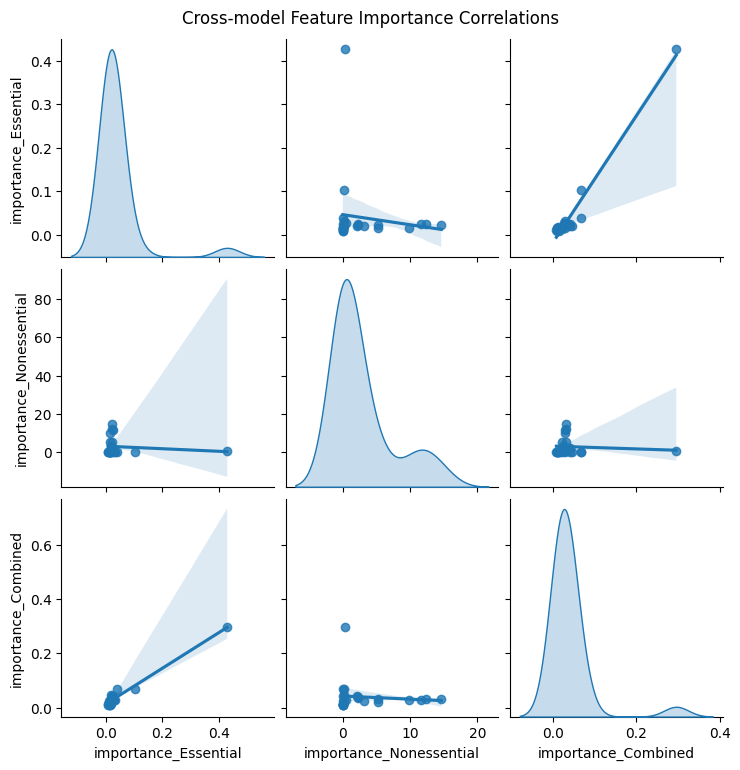

Top-10 overlap (Essential vs Nonessential): 4


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def unwrap_pipeline(model):
    """Return (scaler, estimator) extracted from a Pipeline or plain estimator."""
    scaler = None
    est = model
    
    if isinstance(model, Pipeline):
        # search for StandardScaler and final estimator
        for name, step in model.steps:
            if isinstance(step, StandardScaler):
                scaler = step
            est = step  # last assignment gives final estimator
    return scaler, est


def get_feature_importances(model, X, label):
    """
    Compute feature importances.
    If model is linear + StandardScaler is present → back-transform coefficients.
    If model is RF → raw feature_importances_.
    """
    # Unwrap pipeline
    scaler, est = unwrap_pipeline(model)

    # ---- Tree-based models ----
    if hasattr(est, "feature_importances_"):
        importances = est.feature_importances_

    # ---- Linear models with coef_ ----
    elif hasattr(est, "coef_"):
        coef = est.coef_

        # Handle shape (1, n_features) or (n_features,)
        if coef.ndim == 2 and coef.shape[0] == 1:
            coef = coef.flatten()

        # If StandardScaler is used → unscale coefficients
        if scaler is not None and hasattr(scaler, "scale_"):
            # original-space coefficients: beta_orig = beta_scaled / sigma
            importances = np.abs(coef / scaler.scale_)
        else:
            # No scaling applied
            importances = np.abs(coef)

    else:
        raise AttributeError(
            f"Estimator {type(est).__name__} has neither coef_ nor feature_importances_."
        )

    # ---- Build importance dataframe ----
    df = pd.DataFrame({
        "feature": X.columns,
        f"importance_{label}": importances
    })

    df[f"rank_{label}"] = (
        df[f"importance_{label}"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    return df.sort_values(by=f"importance_{label}", ascending=False).reset_index(drop=True)

# def get_feature_importances(model, X, label):
#     """
#     Compute feature importances for both linear (coef_) and tree-based (feature_importances_) models.

#     Returns a DataFrame with columns:
#     - feature
#     - importance_<label>
#     - rank_<label>
#     """
#     if hasattr(model, "feature_importances_"):   # RandomForest, XGBoost, etc.
#         importances = model.feature_importances_

#     elif hasattr(model, "coef_"):                # LogisticRegression, Ridge
#         importances = np.abs(model.coef_).flatten()

#     else:
#         raise AttributeError(
#             f"Model type {type(model).__name__} has neither coef_ nor feature_importances_."
#         )

#     df = pd.DataFrame({
#         "feature": X.columns,
#         f"importance_{label}": importances
#     })
#     df[f"rank_{label}"] = df[f"importance_{label}"].rank(ascending=False).astype(int)
#     df = df.sort_values(by=f"importance_{label}", ascending=False).reset_index(drop=True)

#     return df

def derive_feature_groups(feature_names):
    """
    Assign each feature to a biological group based on its prefix or name.
    """
    groups = {}
    for feat in feature_names:
        if feat.startswith("Rosetta_"):
            groups.setdefault("Forcefield_Energy", []).append(feat)
        elif feat.startswith("LLR_dim"):
            groups.setdefault("Expanded_LLR", []).append(feat)
        elif feat.startswith("AAIndex_mut"):
            groups.setdefault("Mutational_AAIndex", []).append(feat)
        elif "Prox" in feat:
            groups.setdefault("Structural_Context", []).append(feat)
        else:
            groups.setdefault("Misc", []).append(feat)
    return groups

model_dict = {
    "Essential": (trained_models["Essential_rf"], X_ess),
    "Nonessential": (trained_models["Nonessential_logistic"], X_noness),
    "Combined": (trained_models["Combined_rf"], X_combined)
}

dfs = []
for label, (m, X) in model_dict.items():
    print(label)
    dfs.append(get_feature_importances(m, X, label))

merged_importances = dfs[0]
for df in dfs[1:]:
    merged_importances = merged_importances.merge(df, on="feature", how="outer")
merged_importances = merged_importances.fillna(0)
merged_importances.to_csv("./results/eval_model_feature_importances_merged.csv", index=False)



sns.pairplot(
    merged_importances[[
        "importance_Essential",
        "importance_Nonessential",
        "importance_Combined"
    ]],
    kind="reg", diag_kind="kde"
)
plt.suptitle("Cross-model Feature Importance Correlations", y=1.02)
plt.savefig("./results/cross_model_feature_imp_corr.png", dpi=300)
plt.show()
topk_overlap = len(
    set(merged_importances.sort_values("importance_Essential", ascending=False).head(10)["feature"]) &
    set(merged_importances.sort_values("importance_Nonessential", ascending=False).head(10)["feature"])
)
print(f"Top-10 overlap (Essential vs Nonessential): {topk_overlap}")


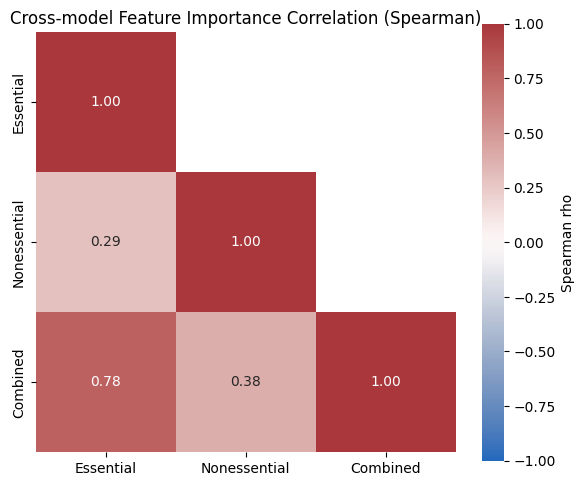

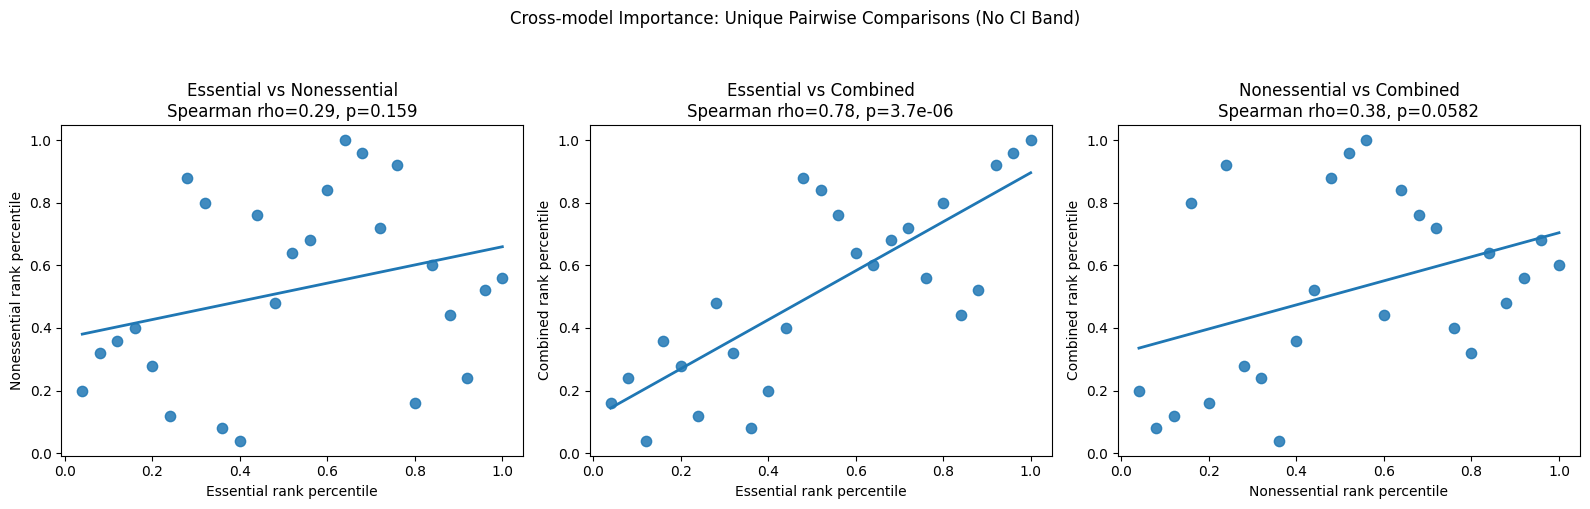

Saved:
 - ./results/cross_model_feature_rank_percentiles.csv
 - ./results/cross_model_feature_rank_spearman.csv
 - ./results/cross_model_feature_imp_spearman_lower_triangle.png
 - ./results/cross_model_feature_imp_rank_scatter_unique_pairs.png


In [38]:
# Publication-ready cross-model importance comparison (rank-based, no duplicated panels)
from scipy.stats import spearmanr

imp_cols = [
    "importance_Essential",
    "importance_Nonessential",
    "importance_Combined",
]

rank_df = merged_importances[["feature"] + imp_cols].copy()
rank_map = {
    "importance_Essential": "rankpct_Essential",
    "importance_Nonessential": "rankpct_Nonessential",
    "importance_Combined": "rankpct_Combined",
}
for src, dst in rank_map.items():
    rank_df[dst] = rank_df[src].rank(method="average", pct=True)

rank_cols = list(rank_map.values())

# Save rank-percentile table for reproducibility
rank_df.to_csv("./results/cross_model_feature_rank_percentiles.csv", index=False)

# Spearman on rank-percentiles (equivalent to rank-based correlation)
spearman_mat = rank_df[rank_cols].corr(method="spearman")
spearman_mat.to_csv("./results/cross_model_feature_rank_spearman.csv")

# 1) Lower-triangle Spearman heatmap (no duplicate upper triangle)
plt.figure(figsize=(6, 5))
mask = np.triu(np.ones_like(spearman_mat, dtype=bool), k=1)
axis_labels = [c.replace("rankpct_", "") for c in rank_cols]

sns.heatmap(
    spearman_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=axis_labels,
    yticklabels=axis_labels,
    cbar_kws={"label": "Spearman rho"},
)
plt.title("Cross-model Feature Importance Correlation (Spearman)")
plt.tight_layout()
plt.savefig("./results/cross_model_feature_imp_spearman_lower_triangle.pdf", dpi=300)
plt.show()

# 2) Unique pairwise scatter plots with simple regression line, no CI shading
pairs = [
    ("rankpct_Essential", "rankpct_Nonessential"),
    ("rankpct_Essential", "rankpct_Combined"),
    ("rankpct_Nonessential", "rankpct_Combined"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=False, sharey=False)

for ax, (x, y) in zip(axes, pairs):
    sns.regplot(
        data=rank_df,
        x=x,
        y=y,
        ci=None,
        scatter_kws={"s": 55, "alpha": 0.85},
        line_kws={"linewidth": 2},
        ax=ax,
    )
    rho, pval = spearmanr(rank_df[x], rank_df[y])
    ax.set_xlabel(f"{x.replace('rankpct_', '')} rank percentile")
    ax.set_ylabel(f"{y.replace('rankpct_', '')} rank percentile")
    ax.set_title(f"{x.replace('rankpct_', '')} vs {y.replace('rankpct_', '')}\nSpearman rho={rho:.2f}, p={pval:.3g}")

plt.suptitle("Cross-model Importance: Unique Pairwise Comparisons (No CI Band)", y=1.05)
plt.tight_layout()
plt.savefig("./results/cross_model_feature_imp_rank_scatter_unique_pairs.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - ./results/cross_model_feature_rank_percentiles.csv")
print(" - ./results/cross_model_feature_rank_spearman.csv")
print(" - ./results/cross_model_feature_imp_spearman_lower_triangle.png")
print(" - ./results/cross_model_feature_imp_rank_scatter_unique_pairs.png")



,group,importance_Essential,importance_Nonessential,importance_Combined
0,Expanded_LLR,0.2163,0.9750,0.3184
1,Forcefield_Energy,0.2486,0.0146,0.2811
2,Mutational_AAIndex,0.1072,0.0056,0.1049
3,Structural_Context,0.4279,0.0048,0.2956


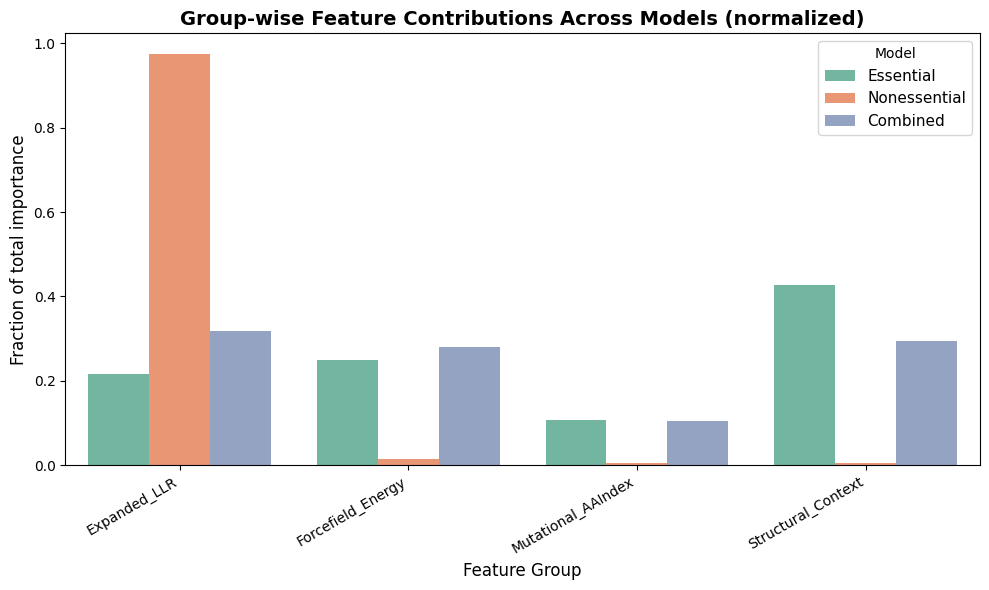

In [39]:
# --- 1. Create feature→group mapping
groups = derive_feature_groups(merged_importances["feature"])
feature_to_group = {f: g for g, feats in groups.items() for f in feats}

# --- 2. Map and group-sum importances
grouped_summary = (
    merged_importances
    .assign(group=merged_importances["feature"].map(feature_to_group))
    .groupby("group")[[
        "importance_Essential",
        "importance_Nonessential",
        "importance_Combined"
    ]]
    .sum()
    .reset_index()
)

# --- 3. Normalize within each model to fractions
for col in ["importance_Essential", "importance_Nonessential", "importance_Combined"]:
    total = grouped_summary[col].sum()
    if total != 0:
        grouped_summary[col] = grouped_summary[col] / total

display(grouped_summary.round(4))

# Melt for grouped barplot
df_plot = grouped_summary.melt(
    id_vars="group",
    var_name="Model",
    value_name="Fraction"
)
df_plot["Model"] = df_plot["Model"].str.replace("importance_", "")

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot,
    x="group", y="Fraction", hue="Model",
    palette="Set2"
)
plt.title("Group-wise Feature Contributions Across Models (normalized)", fontsize=14, weight="bold")
plt.xlabel("Feature Group", fontsize=12)
plt.ylabel("Fraction of total importance", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model", fontsize=11)
plt.tight_layout()
plt.savefig("./results/models_groupwise_feature_contributions_normalized.png", dpi=300)
plt.show()


## SHAP summary for the final Combined RF model

This section refits the Combined random forest on the full 2021 labeled, feature-complete dataset and generates a SHAP beeswarm, a SHAP bar summary, and a table of mean absolute SHAP values. These outputs are intended for manuscript figures and supplement-ready interpretation of the main frozen deployment model.


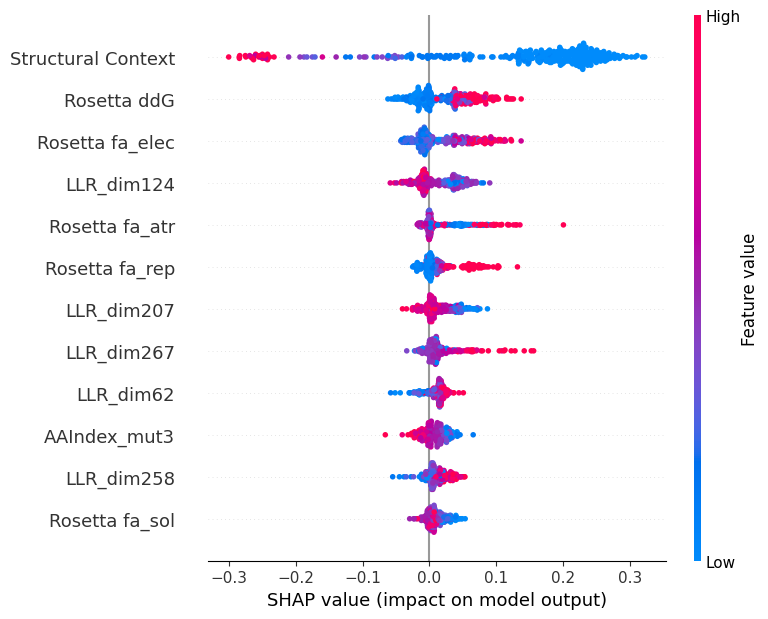

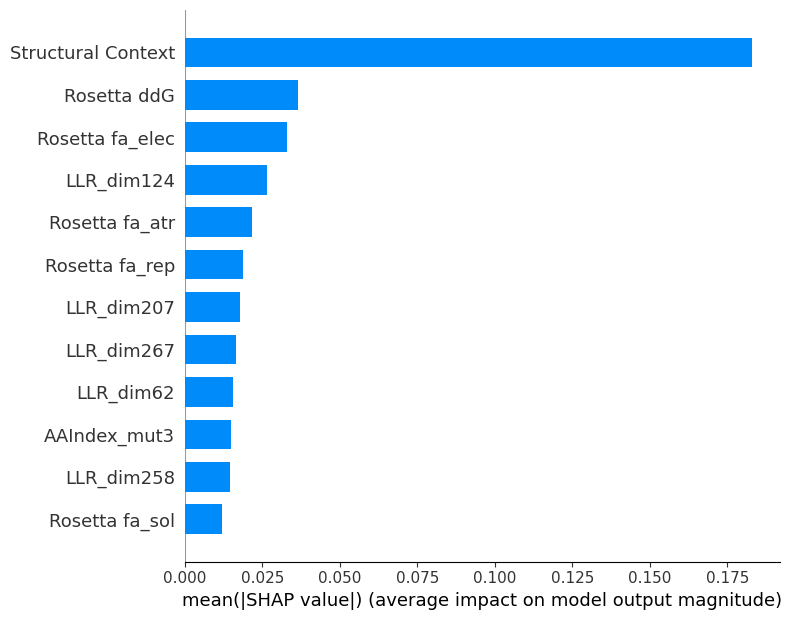

,feature,mean_abs_shap
6,Prox_3D_zeroed,0.182896
5,Rosetta_ddG,0.036615
3,Rosetta_fa_elec,0.032791
11,LLR_dim124,0.026508
0,Rosetta_fa_atr,0.021544
1,Rosetta_fa_rep,0.018784
13,LLR_dim207,0.017665
15,LLR_dim267,0.016609
9,LLR_dim62,0.015583
19,AAIndex_mut3,0.014982


Saved SHAP outputs to results/shap


In [40]:
# SHAP summary for the Combined RF model used in forecasting
from pathlib import Path
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

try:
    import shap
except ImportError:
    raise ImportError("Please install the shap package in this environment before running this cell.")

shap_dir = Path("./results/shap")
shap_dir.mkdir(parents=True, exist_ok=True)

# Refit on the full labeled Combined dataset for global interpretation of the deployment regime
combined_rf_shap = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
combined_rf_shap.fit(X_combined, y_combined)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    explainer = shap.TreeExplainer(combined_rf_shap)
    shap_values_raw = explainer.shap_values(X_combined)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif getattr(shap_values_raw, "ndim", None) == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

display_names = {
    "Rosetta_fa_atr": "Rosetta fa_atr",
    "Rosetta_fa_rep": "Rosetta fa_rep",
    "Rosetta_fa_sol": "Rosetta fa_sol",
    "Rosetta_fa_elec": "Rosetta fa_elec",
    "Rosetta_fa_dun": "Rosetta fa_dun",
    "Rosetta_ddG": "Rosetta ddG",
    "Prox_3D_zeroed": "Structural Context",
}
X_combined_disp = X_combined.rename(columns=display_names)

plt.figure(figsize=(8.5, 7.5))
shap.summary_plot(shap_values, X_combined_disp, show=False, max_display=12)
plt.tight_layout()
plt.savefig(shap_dir / "Combined_RF_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7.5, 6.0))
shap.summary_plot(shap_values, X_combined_disp, show=False, plot_type="bar", max_display=12)
plt.tight_layout()
plt.savefig(shap_dir / "Combined_RF_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

mean_abs_shap = pd.DataFrame({
    "feature": X_combined.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
mean_abs_shap.to_csv(shap_dir / "Combined_RF_shap_mean_abs.csv", index=False)
display(mean_abs_shap.head(12))
print("Saved SHAP outputs to", shap_dir)


/scratch/login/ipykernel_2981074/2045366976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="phenotype_simple", y=feat, ax=ax, palette=["#b9c6c9", "#b8a0b6"])
/scratch/login/ipykernel_2981074/2045366976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="phenotype_simple", y=feat, ax=ax, palette=["#b9c6c9", "#b8a0b6"])
/scratch/login/ipykernel_2981074/2045366976.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="phenotype_simple", y=feat, ax=ax, palette=["#b9c6c9", "#b8a0b6"])
/scratc

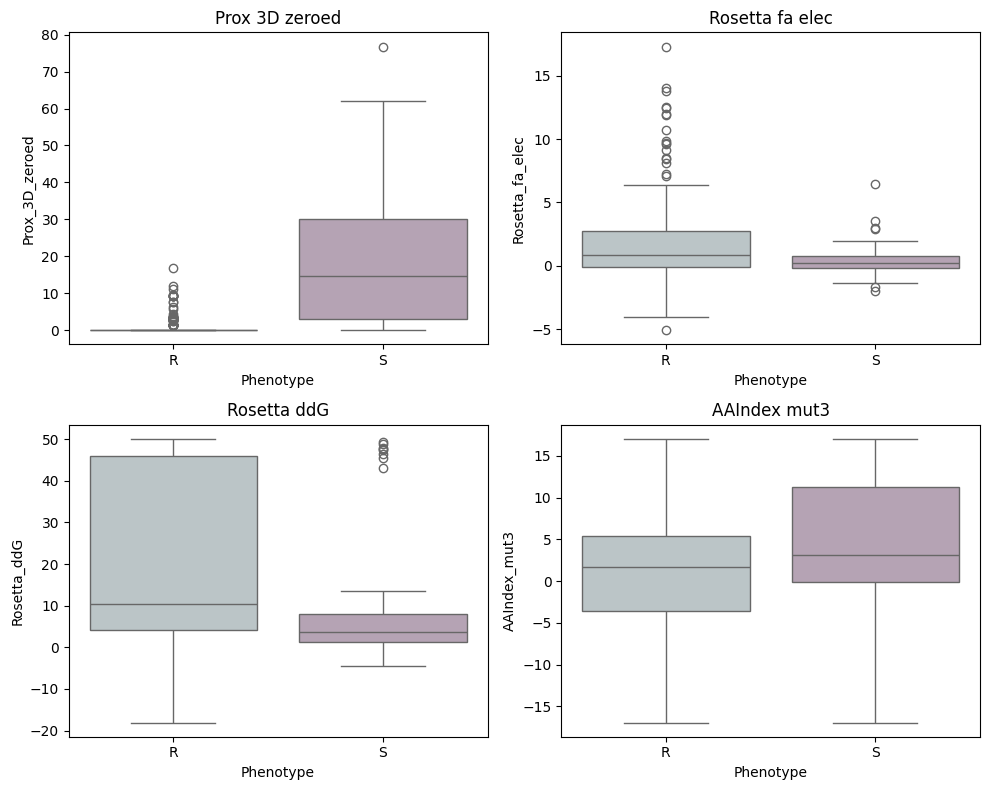

In [41]:
# Optional supplement-style boxplots for a few interpretable Combined-model features
top_interpretable = ["Prox_3D_zeroed", "Rosetta_fa_elec", "Rosetta_ddG", "AAIndex_mut3"]
plot_df = label_data.copy()
plot_df["phenotype_simple"] = plot_df["binary_confidence"].map({0: "S", 1: "R"})
plot_df = plot_df.dropna(subset=top_interpretable)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for ax, feat in zip(axes, top_interpretable):
    sns.boxplot(data=plot_df, x="phenotype_simple", y=feat, ax=ax, palette=["#b9c6c9", "#b8a0b6"])
    ax.set_title(feat.replace("_", " "))
    ax.set_xlabel("Phenotype")
    ax.set_ylabel(feat)
plt.tight_layout()
plt.savefig(shap_dir / "Combined_RF_top_feature_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
import glob
import pandas as pd
import os

incorrect_files = glob.glob("./results/incorrect_predictions/*_incorrect_predictions.csv")
dfs = []
for f in incorrect_files:
    base = os.path.basename(f).replace("_incorrect_predictions.csv", "")
    parts = base.split("_")
    dataset = parts[0]
    model_type = parts[-1] if len(parts) > 1 else ""
    df = pd.read_csv(f)
    df["model_label"] = dataset
    df["model_type"] = model_type.upper()
    df["model_label_full"] = base
    dfs.append(df)

incorrect_all = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print("Total incorrect samples:", len(incorrect_all))
print("Model labels present:", incorrect_all.get("model_label", pd.Series()).unique())


Total incorrect samples: 33
Model labels present: ['Essential' 'Nonessential' 'Combined']


In [44]:
# Map features → groups
numeric_features = list(X_ess.columns)  
groups = derive_feature_groups(numeric_features)
feature_to_group = {f: g for g, feats in groups.items() for f in feats}

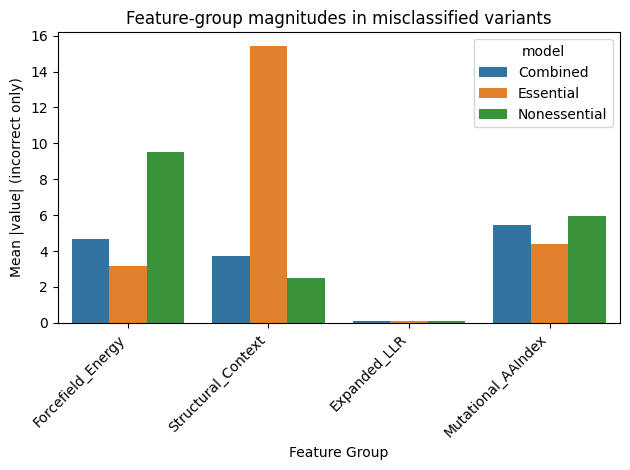

In [45]:
## which biological feature shifts most in misclassification


group_means = []
for lab, sub in incorrect_all.groupby("model_label"):
    tmp = {"model": lab}
    for feat, grp in feature_to_group.items():
        pass  # not needed here
    for gname, feats in groups.items():
        feats = [f for f in feats if f in incorrect_all.columns]
        if feats:
            tmp[gname] = sub[feats].apply(pd.to_numeric, errors="coerce").abs().mean().mean()
    group_means.append(tmp)
plot_df = pd.DataFrame(group_means).melt(id_vars="model", var_name="Feature Group", value_name="Mean|value|")
sns.barplot(data=plot_df, x="Feature Group", y="Mean|value|", hue="model")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Feature Group")
plt.ylabel("Mean |value| (incorrect only)")
plt.title('Feature-group magnitudes in misclassified variants')
plt.tight_layout()
plt.savefig('results/incorrect_predictions/feature_group_magnitude_misclassified_variants.png', dpi=300)


## error analysis

/scratch/login/ipykernel_2981074/2714753744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scratch/login/ipykernel_2981074/2714753744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scratch/login/ipykernel_2981074/2714753744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scratch/login/ipykernel_2981074/2714753744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scr

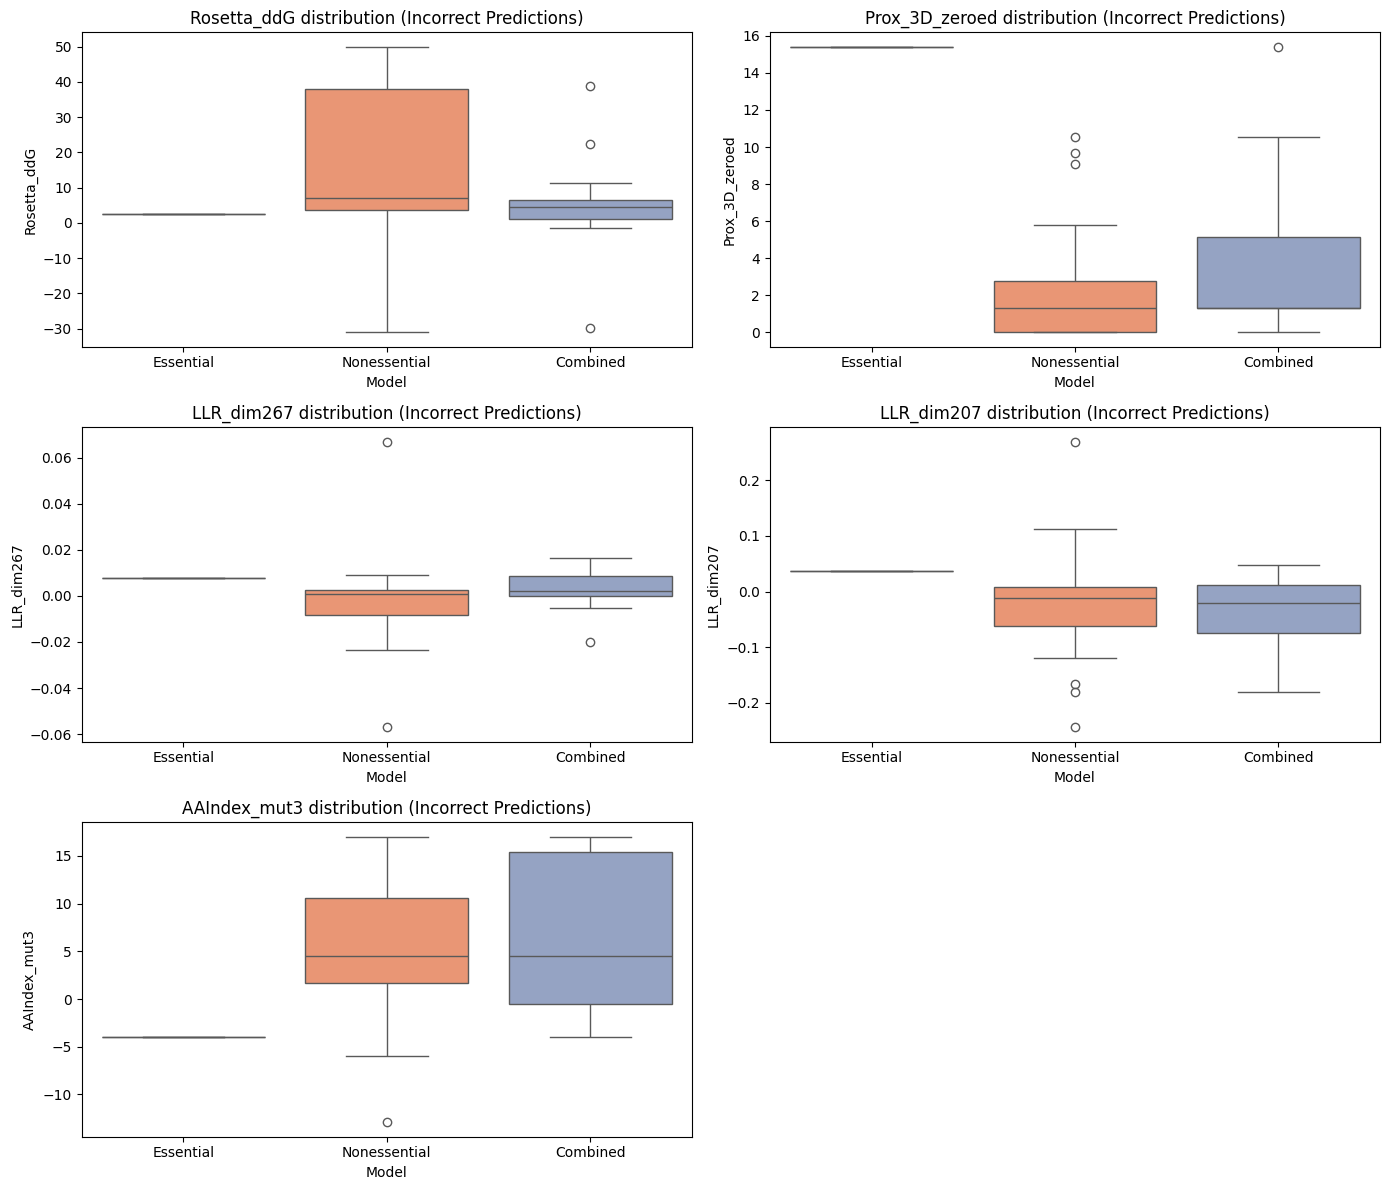

In [49]:

#what happens on these features
# How do the misclassified samples differ between models along specific high-impact features?
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ["Rosetta_ddG", "Prox_3D_zeroed", "LLR_dim267", "LLR_dim207", "AAIndex_mut3"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    sns.boxplot(
        data=incorrect_all,
        x="model_label", y=feat,
        palette="Set2",
        ax=ax
    )
    ax.set_title(f"{feat} distribution (Incorrect Predictions)")
    ax.set_xlabel("Model")
    ax.set_ylabel(feat)

# hide the unused last subplot if you keep a 3x2 grid
if len(features_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("./results/incorrect_predictions/incorrect_feature_distribution_comparison.png", dpi=300)
plt.show()



In [50]:
# Group-level feature means for each model - overall signal strength of incorrect samples per biological group
# Define numeric feature columns once


group_summaries = []

for model_name, group in incorrect_all.groupby("model_label"):
    tmp = {"Model": model_name}
    for grp_name, feats in groups.items():
        # Keep only features present in numeric_features
        valid_feats = [f for f in feats if f in numeric_features]
        if valid_feats:
            tmp[grp_name] = group[valid_feats].apply(pd.to_numeric, errors='coerce').abs().mean().mean()
        else:
            tmp[grp_name] = np.nan
    group_summaries.append(tmp)

group_summary_df = pd.DataFrame(group_summaries).melt(
    id_vars="Model",
    var_name="Feature_Group",
    value_name="Mean_Abs_Value"
)

display(group_summary_df)



,Model,Feature_Group,Mean_Abs_Value
0,Combined,Forcefield_Energy,4.680084
1,Essential,Forcefield_Energy,3.155385
2,Nonessential,Forcefield_Energy,9.490360
3,Combined,Structural_Context,3.710242
4,Essential,Structural_Context,15.416151
5,Nonessential,Structural_Context,2.503618
6,Combined,Expanded_LLR,0.078984
7,Essential,Expanded_LLR,0.099014
8,Nonessential,Expanded_LLR,0.089028
9,Combined,Mutational_AAIndex,5.425942


## wrong predictions per gene

In [53]:
# ------------------------
# MODEL MAPPING
# ------------------------
model_map = {
    "Essential": "RF",
    "Combined": "RF",
    "Nonessential": "LOGISTIC"
}

labels = ["Essential", "Nonessential", "Combined"]

# Ensure the hardcoded map aligns with the selected best_models
if 'best_models' in globals():
    for lab in labels:
        best = best_models.get(lab)
        if best:
            expected = str(best["model_name"]).upper()
            mapped = str(model_map.get(lab, "")).upper()
            if mapped != expected:
                raise ValueError(f"model_map for {lab} is {mapped} but best_models expects {expected}; update model_map or regenerate artifacts so they match.")


    model_label  gene  misclassified_count
3      Combined  pncA                    9
0      Combined   gid                    3
1      Combined  gyrA                    1
2      Combined  gyrB                    1
4     Essential  gyrB                    1
7  Nonessential  pncA                   12
6  Nonessential   gid                    5
5  Nonessential  ethA                    1


/scratch/login/ipykernel_2981074/2590117216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")


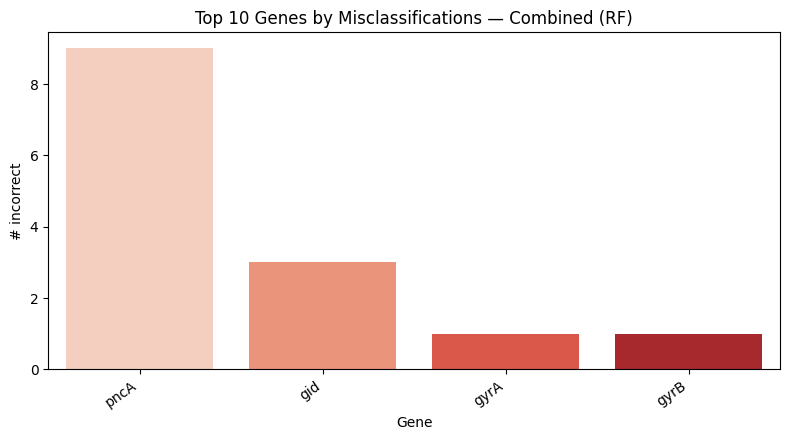

/scratch/login/ipykernel_2981074/2590117216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")


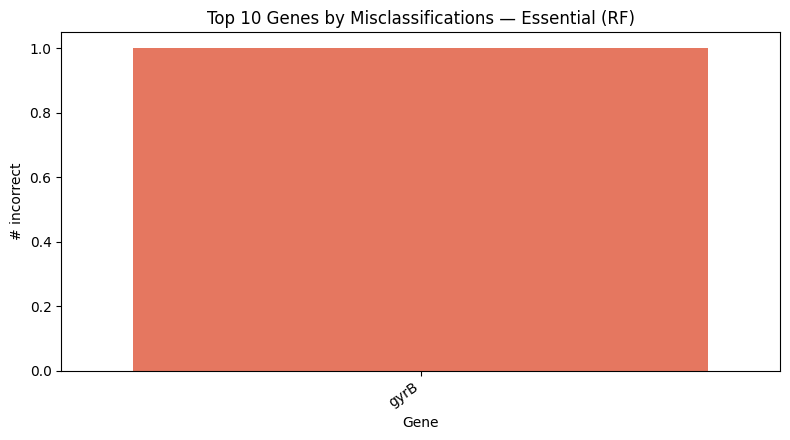

/scratch/login/ipykernel_2981074/2590117216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")


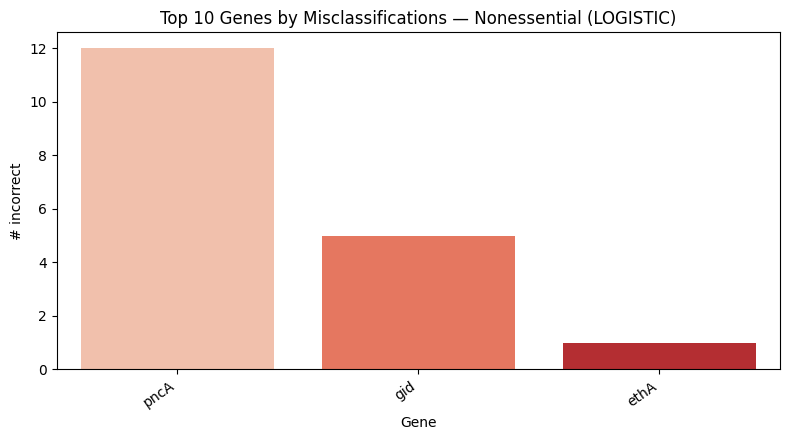

In [54]:
# 2) which genes had the most misclassifications?
# Count per gene & model
mis_by_gene = (incorrect_all
               .groupby(["model_label", "gene"])
               .size()
               .reset_index(name="misclassified_count")
               .sort_values(["model_label", "misclassified_count"], ascending=[True, False]))

print(mis_by_gene.head(20))

# Plot top-N for each model_label
N = 10
os.makedirs("./results/error_analysis", exist_ok=True)

for lab, sub in mis_by_gene.groupby("model_label"):
    # tolerate filenames like Combined_RF by stripping the model suffix if present
    lab_clean = lab.split("_")[0]
    model_type = model_map.get(lab_clean) or model_map.get(lab)
    if model_type is None:
        raise KeyError(f"No model_map entry for label '{lab}' (clean='{lab_clean}')")

    top = sub.head(N)
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=top, x="gene", y="misclassified_count", palette="Reds")
    
    plt.title(f"Top {N} Genes by Misclassifications — {lab_clean} ({model_type})")
    plt.xlabel("Gene"); plt.ylabel("# incorrect")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    
    plt.savefig(
        f"./results/error_analysis/{lab_clean}_{model_type}_top{N}_misclassified_genes.png",
        dpi=300
    )
    plt.show()


In [58]:
# are incorrect calls farther from R variants
# If Prox_3D_zeroed is lower = closer, higher = farther
dist_rows = []
for lab in labels:
    df = all_preds_aug[all_preds_aug["model_label"] == lab]
    if prox_col and prox_col in df.columns:
        tmp = (
            df.groupby(["gene", "correct"])[prox_col]
              .median()
              .unstack("correct")
              .rename(columns={True: "median_prox_correct", False: "median_prox_incorrect"}))
        # Ensure both columns exist (fill missing ones with NaN)
        for col in ["median_prox_correct", "median_prox_incorrect"]:
            if col not in tmp.columns:
                tmp[col] = np.nan

        # Compute delta safely
        tmp["delta_incorrect_minus_correct"] = tmp["median_prox_incorrect"] - tmp["median_prox_correct"]
        tmp["model_label"] = lab
        dist_rows.append(tmp.reset_index())

if dist_rows:
    prox_summary = pd.concat(dist_rows, ignore_index=True)
    prox_summary.to_csv("./results/error_analysis/proximity_incorrect_minus_correct_summary.csv", index=False)
    display(prox_summary.sort_values("delta_incorrect_minus_correct", ascending=False).head(20))


correct,gene,median_prox_incorrect,median_prox_correct,delta_incorrect_minus_correct,model_label
1,gyrB,15.416151,0.000000,15.416151,Essential
9,gyrB,15.416151,0.000000,15.416151,Combined
3,ethA,9.673356,2.803725,6.869631,Nonessential
7,gid,9.104779,2.311968,6.792810,Combined
11,pncA,1.327507,0.000000,1.327507,Combined
5,pncA,0.000000,0.000000,0.000000,Nonessential
0,gyrA,NaN,1.327943,NaN,Essential
2,katG,NaN,0.000000,NaN,Essential
4,gid,5.808522,NaN,NaN,Nonessential
6,ethA,NaN,6.238540,NaN,Combined


In [60]:
group_delta_summary = []

for lab, sub in all_preds_aug.groupby("model_label"):
    tmp = {
        "model_label": lab,
        "model_type": model_map[lab]   # add correct model
    }
    for grp_name, feats in groups.items():
        feats = [f for f in feats if f in sub.columns]
        if not feats:
            continue

        correct_vals = sub.loc[sub["correct"], feats].apply(pd.to_numeric, errors="coerce").abs().mean().mean()
        incorrect_vals = sub.loc[~sub["correct"], feats].apply(pd.to_numeric, errors="coerce").abs().mean().mean()

        tmp[f"{grp_name}_correct_mean"] = correct_vals
        tmp[f"{grp_name}_incorrect_mean"] = incorrect_vals
        tmp[f"{grp_name}_delta"] = incorrect_vals - correct_vals

    group_delta_summary.append(tmp)

group_delta_df = pd.DataFrame(group_delta_summary)
display(group_delta_df)
group_delta_df.to_csv("./results/error_analysis/group_feature_delta_summary.csv", index=False)


,model_label,model_type,Forcefield_Energy_correct_mean,Forcefield_Energy_incorrect_mean,Forcefield_Energy_delta,Structural_Context_correct_mean,Structural_Context_incorrect_mean,Structural_Context_delta,Expanded_LLR_correct_mean,Expanded_LLR_incorrect_mean,Expanded_LLR_delta,Mutational_AAIndex_correct_mean,Mutational_AAIndex_incorrect_mean,Mutational_AAIndex_delta
0,Combined,RF,12.315413,4.680084,-7.635329,1.401833,3.710242,2.308409,0.094079,0.078984,-0.015095,6.527756,5.425942,-1.101814
1,Essential,RF,1.738739,3.155385,1.416647,2.836332,15.416151,12.579819,0.126373,0.099014,-0.027358,4.763900,4.395735,-0.368165
2,Nonessential,LOGISTIC,12.763425,9.490360,-3.273065,1.127895,2.503618,1.375724,0.085454,0.089028,0.003574,6.738134,5.944743,-0.793391


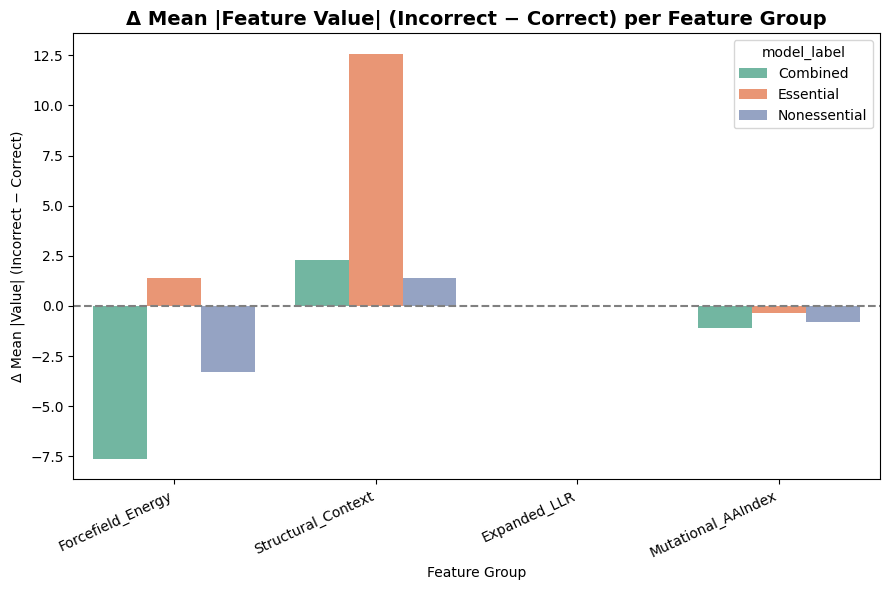

In [61]:
# melt for plotting
melt_cols = [c for c in group_delta_df.columns if c.endswith("_delta")]
plot_df = (
    group_delta_df
    .melt(id_vars="model_label", value_vars=melt_cols,
          var_name="Feature_Group", value_name="Delta_Incorrect_minus_Correct")
)

# clean group names
plot_df["Feature_Group"] = plot_df["Feature_Group"].str.replace("_delta", "", regex=False)

# plot
plt.figure(figsize=(9,6))
sns.barplot(
    data=plot_df,
    x="Feature_Group", y="Delta_Incorrect_minus_Correct",
    hue="model_label", palette="Set2"
)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Δ Mean |Feature Value| (Incorrect − Correct) per Feature Group", fontsize=14, weight="bold")
plt.ylabel("Δ Mean |Value| (Incorrect − Correct)")
plt.xlabel("Feature Group")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("./results/error_analysis/group_feature_deltas_barplot.png", dpi=300)
plt.show()


## 6. Full 2023 mutation-level forecasting

Apply the selected models to the mutation-collapsed 2023 uncertain-significance set and export the deployment-style forecast summaries used in the paper.


## forecast on all unclassified 2023 variants

In [62]:
# Forecast on 2023 unclassified (Category 3) variants using best models
import os

# Keep same essential/nonessential partitioning used during training
nonessential_genes = sorted(
    label_data.loc[label_data["essentiality"] == "nonessential", "gene"].dropna().unique().tolist()
)

# Ensure best_models is available
if 'best_models' not in globals() or not best_models:
    holdout_df = training_results_df[training_results_df["mode"] == "holdout"].copy()
    holdout_df = holdout_df.sort_values(["dataset", "auc"], ascending=[True, False])
    best_rows = holdout_df.groupby("dataset").first().reset_index()
    best_models = {}
    for _, row in best_rows.iterrows():
        key = f"{row['dataset']}_{row['model']}"
        best_models[row['dataset']] = {
            "model_name": row['model'],
            "threshold": row['threshold'],
            "key": key,
        }
    print("[INFO] Rebuilt best_models from training_results_df")

# Build unclassified 2023 subset at mutation level
if 'df_2023' not in globals():
    df_2023 = pd.read_csv(file_2023)
    df_2023 = df_2023[df_2023['Prox_3D'].notna()]

df_2023_uncertain = df_2023[df_2023["confidence"] == "3) Uncertain significance"].copy()
df_2023_uncertain = collapse_to_mutation_level(df_2023_uncertain)
df_2023_uncertain["gene_norm"] = df_2023_uncertain["gene"].str.lower()
df_2023_uncertain["essentiality"] = np.where(
    df_2023_uncertain["gene_norm"].isin([g.lower() for g in nonessential_genes]),
    "Nonessential",
    "Essential",
)
print(f"Mutation-level 2023 uncertain forecast set: {df_2023_uncertain.shape[0]} rows")

forecast_sets = {
    "Essential": (X_ess, df_2023_uncertain[df_2023_uncertain["essentiality"] == "Essential"]),
    "Nonessential": (X_noness, df_2023_uncertain[df_2023_uncertain["essentiality"] == "Nonessential"]),
    "Combined": (X_combined, df_2023_uncertain),
}

def predict_unclassified(df_in, X_ref, model_key, label, threshold):
    if model_key not in trained_models:
        raise KeyError(f"Trained model {model_key} not found.")
    model = trained_models[model_key]
    tmp = df_in.copy()
    missing_cols = [c for c in X_ref.columns if c not in tmp.columns]
    for c in missing_cols:
        tmp[c] = 0
    X_pred = tmp[X_ref.columns].fillna(0)
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_pred)[:, 1]
    else:
        scores = model.decision_function(X_pred)
        rng = scores.max() - scores.min()
        probs = (scores - scores.min()) / (rng if rng != 0 else 1.0)
    preds = (probs >= threshold).astype(int)
    out = tmp.copy()
    out["pred_prob_res"] = probs
    out["pred_label"] = preds
    out["model_label"] = label
    out["model_key"] = model_key
    out["threshold_used"] = threshold
    return out

forecast_outputs = []
summary_rows = []
os.makedirs("./results/forecast_2023_unclassified", exist_ok=True)

for label, (X_ref, df_sub) in forecast_sets.items():
    best = best_models.get(label)
    if best is None:
        print(f"[WARN] No best model for {label}, skipping.")
        continue
    model_key = best["key"]
    threshold = best["threshold"]
    preds_df = predict_unclassified(df_sub, X_ref, model_key, label, threshold)
    preds_path = f"./results/forecast_2023_unclassified/{label}_forecast.csv"
    preds_df.to_csv(preds_path, index=False)
    forecast_outputs.append(preds_df)

    n = len(preds_df)
    frac_res = preds_df["pred_label"].mean() if n else float("nan")
    summary_rows.append({
        "label": label,
        "n_variants": n,
        "frac_pred_resistant": frac_res,
        "model_key": model_key,
        "threshold": threshold,
    })

forecast_all = pd.concat(forecast_outputs, ignore_index=True) if forecast_outputs else pd.DataFrame()
forecast_all.to_csv("./results/forecast_2023_unclassified/all_forecast.csv", index=False)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("./results/forecast_2023_unclassified/summary_by_label.csv", index=False)

# Additional context: run all three selected models on the full mutation-level 2023 uncertain set
full_model_outputs = []
full_model_summary_rows = []
for label, (X_ref, _) in forecast_sets.items():
    best = best_models.get(label)
    if best is None:
        print(f"[WARN] No best model for {label} in full-set comparison, skipping.")
        continue
    model_key = best["key"]
    threshold = best["threshold"]
    preds_df = predict_unclassified(df_2023_uncertain, X_ref, model_key, label, threshold)
    preds_path = f"./results/forecast_2023_unclassified/{label}_on_full_2023_uncertain.csv"
    preds_df.to_csv(preds_path, index=False)
    full_model_outputs.append(preds_df)

    n = len(preds_df)
    frac_res = preds_df["pred_label"].mean() if n else float("nan")
    full_model_summary_rows.append({
        "label": label,
        "n_variants": n,
        "frac_pred_resistant": frac_res,
        "n_pred_resistant": int(preds_df["pred_label"].sum()) if n else 0,
        "model_key": model_key,
        "threshold": threshold,
    })

full_forecast_all = pd.concat(full_model_outputs, ignore_index=True) if full_model_outputs else pd.DataFrame()
full_forecast_all.to_csv("./results/forecast_2023_unclassified/all_models_on_full_2023_uncertain.csv", index=False)

full_summary_df = pd.DataFrame(full_model_summary_rows)
full_summary_df.to_csv("./results/forecast_2023_unclassified/summary_all_models_on_full_2023_uncertain.csv", index=False)
print("Full mutation-level 2023 uncertain-set comparison across selected models:")
display(full_summary_df)
print("Summary by label:")
display(summary_df)

if not forecast_all.empty and "confidence" in forecast_all.columns:
    conf_dist = (forecast_all["confidence"].value_counts(normalize=True) * 100).round(2)
    print("Confidence distribution (%):")
    display(conf_dist)

label_data["gene_norm"] = label_data["gene"].str.lower()
gene_res_counts = label_data.groupby("gene_norm")["binary_confidence"].sum()
genes_no_res = gene_res_counts[gene_res_counts == 0].index
no_res_df = forecast_all[forecast_all["gene_norm"].isin(genes_no_res)].copy()
no_res_df.to_csv("./results/forecast_2023_unclassified/genes_no_res_in_training.csv", index=False)
print("Genes with no resistant variants in training (forecasted):", no_res_df["gene"].nunique())

print("[INFO] Per-drug forecast summaries are skipped in the mutation-level workflow.")
pd.DataFrame(columns=['drug','n_variants','pct_pred_resistant','mean_prob_resistant']).to_csv(
    './results/forecast_2023_unclassified/per_drug_summary.csv', index=False
)



Mutation-level 2023 uncertain forecast set: 4525 rows
Full mutation-level 2023 uncertain-set comparison across selected models:


,label,n_variants,frac_pred_resistant,n_pred_resistant,model_key,threshold
0,Essential,4525,0.195801,886,Essential_rf,0.810
1,Nonessential,4525,0.146740,664,Nonessential_logistic,0.814
2,Combined,4525,0.153812,696,Combined_rf,0.845


Summary by label:


,label,n_variants,frac_pred_resistant,model_key,threshold
0,Essential,3360,0.095833,Essential_rf,0.810
1,Nonessential,1165,0.369957,Nonessential_logistic,0.814
2,Combined,4525,0.153812,Combined_rf,0.845


Confidence distribution (%):


confidence
3) Uncertain significance    100.0
Name: proportion, dtype: float64

Genes with no resistant variants in training (forecasted): 1
[INFO] Per-drug forecast summaries are skipped in the mutation-level workflow.


In [63]:
# Clinical-facing summaries for forecasted 2023 unclassified variants
import os
import pandas as pd

forecast_dir = "./results/forecast_2023_unclassified"
forecast_path = os.path.join(forecast_dir, "all_forecast.csv")
per_drug_path = os.path.join(forecast_dir, "per_drug_summary.csv")

if 'forecast_all' not in globals() or forecast_all is None or forecast_all.empty:
    if os.path.exists(forecast_path):
        forecast_all = pd.read_csv(forecast_path)
        print("Loaded forecast_all from disk", forecast_all.shape)
    else:
        raise ValueError("No forecast_all in memory and file missing; run the forecasting cell first.")

train_support = (
    label_data
    .groupby('gene')
    .agg(
        n_total=('binary_confidence', 'size'),
        n_res=('binary_confidence', 'sum'),
    )
    .reset_index()
)
train_support['n_sus'] = train_support['n_total'] - train_support['n_res']
train_support['evidence_flag'] = pd.cut(
    train_support['n_res'],
    bins=[-1, 0, 2, 1e9],
    labels=['no_resistant', 'low_resistant', 'ok'],
)
train_support.to_csv(os.path.join(forecast_dir, 'training_support_by_gene.csv'), index=False)
print("Training support by gene saved → training_support_by_gene.csv")

if not forecast_all.empty:
    gene_forecast = (
        forecast_all
        .groupby('gene')
        .agg(
            n_variants=('pred_label', 'size'),
            pct_pred_resistant=('pred_label', 'mean'),
            mean_prob_resistant=('pred_prob_res', 'mean'),
        )
        .reset_index()
        .sort_values('pct_pred_resistant', ascending=False)
    )
    gene_forecast.to_csv(os.path.join(forecast_dir, 'gene_forecast_rates.csv'), index=False)
    print("Gene-level forecast rates saved → gene_forecast_rates.csv")
    display(gene_forecast.head(10))
else:
    gene_forecast = pd.DataFrame()
    print("[WARN] forecast_all is empty; skipping gene-level summary.")

print("[INFO] Per-drug summaries are not applicable in the mutation-level workflow.")
if os.path.exists(per_drug_path):
    per_drug = pd.read_csv(per_drug_path)
else:
    per_drug = pd.DataFrame(columns=['drug','n_variants','pct_pred_resistant','mean_prob_resistant'])

print("[INFO] Top predicted resistant/susceptible variants by drug are skipped in the mutation-level workflow.")
pd.DataFrame().to_csv(os.path.join(forecast_dir, 'top_predicted_resistant_by_drug.csv'), index=False)
pd.DataFrame().to_csv(os.path.join(forecast_dir, 'top_predicted_susceptible_by_drug.csv'), index=False)

if not forecast_all.empty and 'confidence' in forecast_all.columns:
    conf_dist = (forecast_all['confidence'].value_counts(normalize=True) * 100).round(2)
    print("Confidence distribution (%):")
    display(conf_dist)

no_res_genes = train_support[train_support['n_res'] == 0]['gene'].tolist()
no_res_df = forecast_all[forecast_all['gene'].isin(no_res_genes)]
no_res_df.to_csv(os.path.join(forecast_dir, 'genes_no_resistant_training_forecast_subset.csv'), index=False)
print(f"Genes with zero resistant training examples in forecast set: {len(no_res_genes)} genes, {len(no_res_df)} variants")
if no_res_genes:
    print("Genes:", no_res_genes)



Training support by gene saved → training_support_by_gene.csv
Gene-level forecast rates saved → gene_forecast_rates.csv


,gene,n_variants,pct_pred_resistant,mean_prob_resistant
10,pncA,294,0.632653,0.777487
5,gid,924,0.392857,0.654313
0,Rv0678,308,0.334416,0.710146
4,ethA,1112,0.323741,0.615304
1,atpE,18,0.277778,0.581667
14,tlyA,186,0.145161,0.581774
13,rpsL,82,0.134146,0.502317
12,rpoB,1348,0.096439,0.509303
3,embB,1458,0.084362,0.492569
7,gyrB,580,0.082759,0.486957


[INFO] Per-drug summaries are not applicable in the mutation-level workflow.
[INFO] Top predicted resistant/susceptible variants by drug are skipped in the mutation-level workflow.
Confidence distribution (%):


confidence
3) Uncertain significance    100.0
Name: proportion, dtype: float64

Genes with zero resistant training examples in forecast set: 1 genes, 172 variants
Genes: ['inhA']


In [64]:
# Training support vs forecast outputs (gene-level only in mutation-level workflow)
import os
import pandas as pd

forecast_dir = "./results/forecast_2023_unclassified"
paths = {
    "forecast_all": os.path.join(forecast_dir, "all_forecast.csv"),
    "train_support": os.path.join(forecast_dir, "training_support_by_gene.csv"),
    "gene_forecast": os.path.join(forecast_dir, "gene_forecast_rates.csv"),
}

forecast_all = pd.read_csv(paths["forecast_all"]) if os.path.exists(paths["forecast_all"]) else pd.DataFrame()
train_support = pd.read_csv(paths["train_support"]) if os.path.exists(paths["train_support"]) else pd.DataFrame()
gene_forecast = pd.read_csv(paths["gene_forecast"]) if os.path.exists(paths["gene_forecast"]) else pd.DataFrame()

if forecast_all.empty:
    raise ValueError("forecast_all.csv missing; run forecasting cell first.")
if train_support.empty:
    raise ValueError("training_support_by_gene.csv missing; run the clinical summary cell first.")

if gene_forecast.empty:
    gene_forecast = (
        forecast_all
        .groupby('gene')
        .agg(
            n_variants=('pred_label', 'size'),
            pct_pred_resistant=('pred_label', 'mean'),
            mean_prob_resistant=('pred_prob_res', 'mean'),
        )
        .reset_index()
    )

merged_gene = train_support.merge(gene_forecast, on='gene', how='left')
merged_gene.to_csv(os.path.join(forecast_dir, 'training_vs_forecast_by_gene.csv'), index=False)
print("Training vs forecast (gene-level) → training_vs_forecast_by_gene.csv")
display(merged_gene.sort_values('pct_pred_resistant', ascending=False).head(10))

print("[INFO] Gene+drug forecast examples are skipped in the mutation-level workflow.")
pd.DataFrame().to_csv(os.path.join(forecast_dir, 'training_vs_forecast_gene_drug_examples.csv'), index=False)



Training vs forecast (gene-level) → training_vs_forecast_by_gene.csv


,gene,n_total,n_res,n_sus,evidence_flag,n_variants,pct_pred_resistant,mean_prob_resistant
7,pncA,167,155.0,12.0,ok,294,0.632653,0.777487
2,gid,9,5.0,4.0,ok,924,0.392857,0.654313
1,ethA,10,10.0,0.0,ok,1112,0.323741,0.615304
10,tlyA,3,3.0,0.0,ok,186,0.145161,0.581774
9,rpsL,4,4.0,0.0,ok,82,0.134146,0.502317
8,rpoB,97,90.0,7.0,ok,1348,0.096439,0.509303
0,embB,21,14.0,7.0,ok,1458,0.084362,0.492569
4,gyrB,9,5.0,4.0,ok,580,0.082759,0.486957
5,inhA,1,0.0,1.0,no_resistant,172,0.046512,0.502500
6,katG,5,3.0,2.0,ok,1636,0.039120,0.507803


[INFO] Gene+drug forecast examples are skipped in the mutation-level workflow.


In [65]:
# Augment training vs forecast outputs with support tiers (gene-level only)
import os
import pandas as pd

forecast_dir = "./results/forecast_2023_unclassified"
paths = {
    "forecast_all": os.path.join(forecast_dir, "all_forecast.csv"),
    "train_support": os.path.join(forecast_dir, "training_support_by_gene.csv"),
    "gene_forecast": os.path.join(forecast_dir, "gene_forecast_rates.csv"),
}

forecast_all = pd.read_csv(paths["forecast_all"]) if os.path.exists(paths["forecast_all"]) else pd.DataFrame()
train_support = pd.read_csv(paths["train_support"]) if os.path.exists(paths["train_support"]) else pd.DataFrame()
gene_forecast = pd.read_csv(paths["gene_forecast"]) if os.path.exists(paths["gene_forecast"]) else pd.DataFrame()

if forecast_all.empty:
    raise ValueError("forecast_all.csv missing; run forecasting cell first.")
if train_support.empty:
    raise ValueError("training_support_by_gene.csv missing; run the clinical summary cell first.")

if gene_forecast.empty:
    gene_forecast = (
        forecast_all
        .groupby('gene')
        .agg(
            n_variants=('pred_label', 'size'),
            pct_pred_resistant=('pred_label', 'mean'),
            mean_prob_resistant=('pred_prob_res', 'mean'),
            n_high_confidence=('pred_prob_res', lambda s: (s >= 0.8).sum()),
        )
        .reset_index()
    )
else:
    if 'n_high_confidence' not in gene_forecast.columns:
        tmp = (
            forecast_all
            .groupby('gene')['pred_prob_res']
            .apply(lambda s: (s >= 0.8).sum())
            .rename('n_high_confidence')
            .reset_index()
        )
        gene_forecast = gene_forecast.merge(tmp, on='gene', how='left')

merged_gene = train_support.merge(gene_forecast, on='gene', how='left')
merged_gene.to_csv(os.path.join(forecast_dir, 'training_vs_forecast_by_gene.csv'), index=False)
print("Updated training_vs_forecast_by_gene.csv with n_high_confidence.")

print("[INFO] Gene+drug support-tier examples are skipped in the mutation-level workflow.")
pd.DataFrame().to_csv(os.path.join(forecast_dir, 'training_vs_forecast_gene_drug_examples.csv'), index=False)



Updated training_vs_forecast_by_gene.csv with n_high_confidence.
[INFO] Gene+drug support-tier examples are skipped in the mutation-level workflow.


## 7. Figure generation

Build the manuscript-ready figure panels from the saved result tables after all upstream analyses have completed.


## Nat Comm Figure 2 panels
Generate compact AUC panels for main-text Figure 2 directly from the saved release result tables. This makes the figure provenance explicit and keeps the Combined model visible in every panel.


In [66]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def resolve_results_dir() -> Path:
    candidates = [Path("./results")]
    required = [
        "training_model_summary.csv",
        "category3_evaluation_summary.csv",
        "proximity_baseline_model_summary.csv",
    ]
    for candidate in candidates:
        if all((candidate / rel).exists() for rel in required):
            return candidate
    raise FileNotFoundError(f"Could not locate results directory from candidates: {candidates}")


def normalize_eval_df(eval_df: pd.DataFrame) -> pd.DataFrame:
    out = eval_df.copy()
    rename_map = {
        "Feature Set": "dataset",
        "Model": "model",
        "ROC AUC": "auc",
        "Optimal Threshold": "threshold",
        "Sensitivity (Res)": "sensitivity",
        "Specificity (Sus)": "specificity",
        "F1 (Res)": "f1_res",
    }
    out = out.rename(columns={k: v for k, v in rename_map.items() if k in out.columns})

    if "dataset" not in out.columns:
        raise KeyError("Expected dataset/Feature Set column in category3 evaluation summary")

    out["dataset"] = out["dataset"].astype(str).str.replace("_Prox_3D_zeroed_Baseline", "", regex=False)
    out["model"] = out.get("model", pd.Series([None] * len(out))).astype(str).str.lower()

    # category3_evaluation_summary.csv stores some metrics as percentages (0-100)
    for col in ["auc", "sensitivity", "specificity", "f1_res"]:
        if col in out.columns and out[col].max() > 1.5:
            out[col] = out[col] / 100.0

    return out


def load_ablation_df(results_dir: Path) -> pd.DataFrame:
    full_path = results_dir / "ablation_full" / "ablation_model_summary.csv"
    simple_path = results_dir / "ablation_model_summary.csv"

    if full_path.exists():
        df = pd.read_csv(full_path)
    else:
        df = pd.read_csv(simple_path)

    df["dataset"] = df["dataset"].astype(str).str.replace("_noLLR_noRosetta", "", regex=False)

    ablation_map = {
        "keep_all": "keep_all",
        "drop_LLR": "drop_LLR",
        "drop_Rosetta": "drop_Rosetta",
        "drop_Proximity": "drop_Proximity",
        "drop_AAIndex": "drop_AAIndex",
        "noLLR_noRosetta": "drop_LLR_Rosetta",
        "drop_LLR_Rosetta": "drop_LLR_Rosetta",
    }
    df["ablation"] = df["ablation"].map(lambda x: ablation_map.get(x, x))
    return df


results_dir = resolve_results_dir()
outdir = results_dir / "figure2_panels"
outdir.mkdir(parents=True, exist_ok=True)

dataset_order = ["Essential", "Nonessential", "Combined"]
dataset_colors = {
    "Essential": "#8BCF88",      # soft pastel green
    "Nonessential": "#F4BEA6",   # soft pastel peach
    "Combined": "#9FC5E8",       # soft pastel blue
}

ablation_colors = {
    "keep_all": "#9FC5E8",        # pastel blue
    "drop_LLR": "#B7E1CD",        # mint
    "drop_Rosetta": "#F7C6C7",    # soft rose
    "drop_Proximity": "#D8C2F0",  # lavender
    "drop_AAIndex": "#F8D9A0",    # pale apricot
}

comparison_colors = {
    "Selected final": "#9FC5E8",      # same Combined-ish pastel blue
    "Best proximity-only": "#D6C4B0", # soft taupe / beige
}


def style_ax(ax, ylabel="AUC"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.70, 1.02)


train_df = pd.read_csv(results_dir / "training_model_summary.csv")
abl_df = load_ablation_df(results_dir)
base_df = pd.read_csv(results_dir / "proximity_baseline_model_summary.csv")
eval_df = normalize_eval_df(pd.read_csv(results_dir / "category3_evaluation_summary.csv"))

# Panel A: selected holdout models
holdout = train_df[train_df["mode"] == "holdout"].copy()
best_holdout = (
    holdout.sort_values(["dataset", "auc"], ascending=[True, False])
    .groupby("dataset")
    .first()
    .reset_index()
)
best_holdout["dataset"] = pd.Categorical(best_holdout["dataset"], dataset_order, ordered=True)
best_holdout = best_holdout.sort_values("dataset")

fig, ax = plt.subplots(figsize=(4.4, 3.2))
bars = ax.bar(
    best_holdout["dataset"],
    best_holdout["auc"],
    color=[dataset_colors[d] for d in best_holdout["dataset"]],
    width=0.65,
)
style_ax(ax)
ax.set_title("A  Holdout performance", loc="left", fontweight="bold")
for bar, val in zip(bars, best_holdout["auc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.008,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(outdir / "fig2A_holdout_auc.pdf", bbox_inches="tight")
plt.close(fig)

# Panel B: temporal evaluation
best_eval = eval_df.copy()
best_eval["dataset"] = pd.Categorical(best_eval["dataset"], dataset_order, ordered=True)
best_eval = best_eval.sort_values("dataset")

fig, ax = plt.subplots(figsize=(4.4, 3.2))
bars = ax.bar(
    best_eval["dataset"],
    best_eval["f1_res"],
    color=[dataset_colors[d] for d in best_eval["dataset"]],
    width=0.65,
)
style_ax(ax, ylabel="F1 (Res)")
ax.set_title("B  Temporal reclassification", loc="left", fontweight="bold")
for bar, val in zip(bars, best_eval["f1_res"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.008,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(outdir / "fig2B_temporal_f1.pdf", bbox_inches="tight")
# fig.savefig(outdir / "fig2B_temporal_auc.pdf", bbox_inches="tight")
plt.close(fig)

# Panel C: ablation AUC for selected best model per dataset
abl_holdout = abl_df[abl_df["mode"] == "holdout"].copy()
selected = []
for ds in dataset_order:
    model = "rf" if ds in ["Essential", "Combined"] else "logistic"
    subset = abl_holdout[
        (abl_holdout["dataset"] == ds)
        & (abl_holdout["model"] == model)
        & (abl_holdout["ablation"].isin(["keep_all", "drop_LLR", "drop_Rosetta", "drop_Proximity", "drop_AAIndex"]))
    ].copy()
    selected.append(subset)

abl_plot = pd.concat(selected, ignore_index=True)
abl_plot["dataset"] = pd.Categorical(abl_plot["dataset"], dataset_order, ordered=True)
abl_plot["ablation"] = pd.Categorical(
    abl_plot["ablation"],
    ["keep_all", "drop_LLR", "drop_Rosetta", "drop_Proximity", "drop_AAIndex"],
    ordered=True,
)
abl_plot = abl_plot.sort_values(["dataset", "ablation"])

pivot = abl_plot.pivot(index="dataset", columns="ablation", values="auc").loc[dataset_order]

fig, ax = plt.subplots(figsize=(6.6, 3.6))
x = range(len(dataset_order))
width_ab = 0.15
offsets = [-2, -1, 0, 1, 2]

for off, ablation in zip(offsets, pivot.columns):
    vals = pivot[ablation].values
    pos = [i + off * width_ab for i in x]
    ax.bar(pos, vals, width=width_ab, color=ablation_colors[ablation], label=ablation.replace("_", " "))

ax.set_xticks(list(x))
ax.set_xticklabels(dataset_order)
style_ax(ax)
ax.set_title("C  Feature-group ablation", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=3, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(outdir / "fig2C_ablation_auc.pdf", bbox_inches="tight")
plt.close(fig)

# Panel D: selected final vs best Prox_3D_zeroed-only baseline
base_holdout = base_df[base_df["mode"] == "holdout"].copy()
base_holdout = base_holdout[base_holdout["features_used"] == "Prox_3D_zeroed"].copy()
base_holdout["dataset_clean"] = base_holdout["dataset"].str.replace("_Prox_3D_zeroed_Baseline", "", regex=False)

base_best = (
    base_holdout.sort_values(["dataset_clean", "auc"], ascending=[True, False])
    .groupby("dataset_clean")
    .first()
    .reset_index()
)
base_best["dataset_clean"] = pd.Categorical(base_best["dataset_clean"], dataset_order, ordered=True)
base_best = base_best.sort_values("dataset_clean")

compare = best_holdout[["dataset", "auc"]].rename(columns={"auc": "Selected final"}).merge(
    base_best[["dataset_clean", "auc"]].rename(
        columns={"dataset_clean": "dataset", "auc": "Best proximity-only"}
    ),
    on="dataset",
    how="left",
)

fig, ax = plt.subplots(figsize=(5.2, 3.2))
x = range(len(dataset_order))
width_cmp = 0.34

bars1 = ax.bar(
    [i - width_cmp / 2 for i in x],
    compare["Selected final"],
    width=width_cmp,
    color=comparison_colors["Selected final"],
    label="Selected final",
)
bars2 = ax.bar(
    [i + width_cmp / 2 for i in x],
    compare["Best proximity-only"],
    width=width_cmp,
    color=comparison_colors["Best proximity-only"],
    label="Best proximity-only",
)

ax.set_xticks(list(x))
ax.set_xticklabels(compare["dataset"])
style_ax(ax)
ax.set_title("D  Final vs. proximity-only", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.008,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

fig.tight_layout()
fig.savefig(outdir / "fig2D_baseline_auc.pdf", bbox_inches="tight")
plt.close(fig)

print("Saved Figure 2 panels to", outdir)
print(" -", outdir / "fig2A_holdout_auc.pdf")
print(" -", outdir / "fig2B_temporal_f1.pdf")
print(" -", outdir / "fig2C_ablation_auc.pdf")
print(" -", outdir / "fig2D_baseline_auc.pdf")


Saved Figure 2 panels to results/figure2_panels
 - results/figure2_panels/fig2A_holdout_auc.pdf
 - results/figure2_panels/fig2B_temporal_f1.pdf
 - results/figure2_panels/fig2C_ablation_auc.pdf
 - results/figure2_panels/fig2D_baseline_auc.pdf


## Nat Comm Figure 2E/F statistical-model comparison
Generate compact panels comparing the selected manuscript models against GAM and GAQQ on the temporally separated Category 3 evaluation set. These panels summarize why the multimodal forecasting framework is more useful than the alternative statistical models in the rare-variant setting.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reuse normalized temporal evaluation results when available.
if 'eval_df' in globals():
    temporal_eval = normalize_eval_df(eval_df.copy()) if 'Feature Set' in eval_df.columns else eval_df.copy()
else:
    temporal_eval = normalize_eval_df(pd.read_csv(results_dir / "category3_evaluation_summary.csv"))

# Keep one selected manuscript model per dataset.
selected_temporal = temporal_eval[["dataset", "auc", "sensitivity"]].copy()
selected_temporal["model_family"] = "Selected manuscript model"
selected_temporal["auc_pct"] = selected_temporal["auc"] * 100.0
selected_temporal["sensitivity_pct"] = selected_temporal["sensitivity"] * 100.0

# Alternative statistical models from the manuscript supplementary comparison table.
statistical_df = pd.DataFrame([
    {"dataset": "Essential", "model_family": "GAM",  "auc_pct": 22.22, "sensitivity_pct": 0.0},
    {"dataset": "Nonessential", "model_family": "GAM",  "auc_pct": 30.39, "sensitivity_pct": 2.0},
    {"dataset": "Combined", "model_family": "GAM",  "auc_pct": 73.37, "sensitivity_pct": 50.0},
    {"dataset": "Essential", "model_family": "GAQQ", "auc_pct": 44.44, "sensitivity_pct": 33.3},
    {"dataset": "Nonessential", "model_family": "GAQQ", "auc_pct": 32.84, "sensitivity_pct": 13.7},
    {"dataset": "Combined", "model_family": "GAQQ", "auc_pct": 20.98, "sensitivity_pct": 5.2},
])

plot_df = pd.concat([
    selected_temporal[["dataset", "model_family", "auc_pct", "sensitivity_pct"]],
    statistical_df
], ignore_index=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], dataset_order, ordered=True)
plot_df["model_family"] = pd.Categorical(
    plot_df["model_family"],
    ["Selected manuscript model", "GAM", "GAQQ"],
    ordered=True,
)
plot_df = plot_df.sort_values(["dataset", "model_family"])

comparison_palette = {
    "Selected manuscript model": "#5FB3B3",  # soft teal
    "GAM": "#94A3B8",                        # cool gray-blue
    "GAQQ": "#D5DDEA",                       # pale slate
}


def style_pct_ax(ax, ylabel):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)


x = range(len(dataset_order))
width = 0.23
offset_lookup = {
    "Selected manuscript model": -width,
    "GAM": 0.0,
    "GAQQ": width,
}

# Panel E: sensitivity
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for family in ["Selected manuscript model", "GAM", "GAQQ"]:
    subset = plot_df[plot_df["model_family"] == family].set_index("dataset").reindex(dataset_order)
    pos = [i + offset_lookup[family] for i in x]
    bars = ax.bar(pos, subset["sensitivity_pct"], width=width, color=comparison_palette[family], label=family)
    for bar, val in zip(bars, subset["sensitivity_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.8, f"{val:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(dataset_order)
style_pct_ax(ax, "Sensitivity (%)")
ax.set_title("E  Statistical models miss resistant variants", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(outdir / "fig2E_statistical_model_sensitivity.pdf", bbox_inches="tight")
fig.savefig(outdir / "fig2E_statistical_model_sensitivity.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# Panel F: AUC
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for family in ["Selected manuscript model", "GAM", "GAQQ"]:
    subset = plot_df[plot_df["model_family"] == family].set_index("dataset").reindex(dataset_order)
    pos = [i + offset_lookup[family] for i in x]
    bars = ax.bar(pos, subset["auc_pct"], width=width, color=comparison_palette[family], label=family)
    for bar, val in zip(bars, subset["auc_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.8, f"{val:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(dataset_order)
style_pct_ax(ax, "ROC-AUC (%)")
ax.axhline(50, linestyle="--", linewidth=1.0, color="#E8A2B8")
ax.text(len(dataset_order) - 0.15, 51.5, "50% random", color="#D16A8A", fontsize=8, ha="right")
ax.set_title("F  Discrimination against rare variants", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(outdir / "fig2F_statistical_model_auc.pdf", bbox_inches="tight")
fig.savefig(outdir / "fig2F_statistical_model_auc.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("Saved:", outdir / "fig2E_statistical_model_sensitivity.pdf")
print("Saved:", outdir / "fig2F_statistical_model_auc.pdf")


## Nat Comm Figure 3 panels
Generate compact interpretability panels for the main-text Figure 3. These panels summarize feature-family contributions, cross-model agreement, gene-level residual errors, and Combined-model SHAP signal using the saved release outputs.

In [67]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import pandas as pd
import seaborn as sns
import numpy as np


def resolve_results_dir() -> Path:
    results_dir = Path("results")
    required = [
        "cross_model_feature_rank_spearman.csv",
        "Essential_RF_predictions_on_category3.csv",
        "Nonessential_LOGISTIC_predictions_on_category3.csv",
        "Combined_RF_predictions_on_category3.csv",
        "error_analysis/proximity_incorrect_minus_correct_summary.csv",
    ]

    if not results_dir.exists():
        raise FileNotFoundError("results/ does not exist yet in this run")

    missing = [rel for rel in required if not (results_dir / rel).exists()]
    if missing:
        raise FileNotFoundError(f"Missing required files in results/: {missing}")

    return results_dir


results_dir = resolve_results_dir()
outdir = results_dir / "figure3_panels"
outdir.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

# Shared panel size for A/B/C/D
PANEL_W = 5.2
PANEL_H = 4.4

model_order = ["Essential", "Nonessential", "Combined"]

modality_colors = {
    "Structural context": {"fill": "#e0f2fe", "text": "#0369a1", "edge": "#bae6fd"},
    "Forcefield energy": {"fill": "#f3e8ff", "text": "#7e22ce", "edge": "#e9d5ff"},
    "Expanded LLR": {"fill": "#fef3c7", "text": "#b45309", "edge": "#fde68a"},
    "Mutational AAIndex": {"fill": "#ffe4e6", "text": "#e11d48", "edge": "#fecdd3"},
}

soft_blue_cmap = sns.light_palette("#9FC5E8", as_cmap=True)
soft_diverging_cmap = sns.diverging_palette(15, 240, s=45, l=75, as_cmap=True)
soft_prox_cmap = sns.diverging_palette(220, 20, s=45, l=75, as_cmap=True)


def feature_family(feature: str) -> str:
    if feature == "Prox_3D_zeroed":
        return "Structural context"
    if feature.startswith("Rosetta_"):
        return "Forcefield energy"
    if feature.startswith("LLR_dim"):
        return "Expanded LLR"
    if feature.startswith("AAIndex_mut"):
        return "Mutational AAIndex"
    return "Other"


def style_heatmap_frame(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)


def save_panel(fig, filename):
    pdf_path = outdir / filename
    png_path = outdir / filename.replace(".pdf", ".png")
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)


# =========================================
# Panel A: Mechanistic drivers by gene stratum
# =========================================
top_features = {
    "Essential (RF)": [
        "Prox_3D_zeroed",
        "Rosetta_fa_elec",
        "LLR_dim62",
        "Rosetta_ddG",
        "AAIndex_mut3",
    ],
    "Nonessential (Logistic)": [
        "LLR_dim258",
        "LLR_dim267",
        "LLR_dim124",
        "LLR_dim33",
        "LLR_dim315",
    ],
    "Combined (RF)": [
        "Prox_3D_zeroed",
        "Rosetta_fa_elec",
        "Rosetta_ddG",
        "LLR_dim124",
        "Rosetta_fa_rep",
    ],
}

legend_labels = {
    "Structural context": "3D STRUCTURAL CONTEXT",
    "Forcefield energy": "ROSETTA BIOPHYSICS",
    "Expanded LLR": "ESM-2 LIKELIHOOD (LLR)",
    "Mutational AAIndex": "AAINDEX DESCRIPTORS",
}


def plot_fig3a(ax):
    ax.set_xlim(0, 9.4)
    ax.set_ylim(1.0, 6.7)
    ax.axis("off")

    ax.text(
        0.20, 6.28,
        "A. Mechanistic Drivers of Resistance by Gene Stratum",
        fontsize=15.5, fontweight="bold", ha="left", va="center", color="black"
    )

    col_x = {
        "Essential (RF)": 0.9,
        "Nonessential (Logistic)": 3.35,
        "Combined (RF)": 5.80,
    }
    box_w = 2.0
    box_h = 0.56
    row_start_y = 5.02
    row_gap = 0.72

    for col, x in col_x.items():
        ax.text(
            x + box_w / 2, 5.70,
            col,
            fontsize=10.8, fontweight="bold",
            ha="center", va="center", color="black"
        )

    for i in range(5):
        y = row_start_y - i * row_gap
        ax.text(
            0.45, y + box_h / 2,
            str(i + 1),
            fontsize=13.5, ha="center", va="center", color="black"
        )

    for col, feats in top_features.items():
        x = col_x[col]
        for i, feat in enumerate(feats):
            y = row_start_y - i * row_gap
            family = feature_family(feat)
            style = modality_colors[family]

            patch = FancyBboxPatch(
                (x, y), box_w, box_h,
                boxstyle="round,pad=0.02,rounding_size=0.08",
                linewidth=0.85,
                edgecolor=style["edge"],
                facecolor=style["fill"],
            )
            ax.add_patch(patch)

            ax.text(
                x + 0.10, y + box_h / 2,
                feat,
                fontsize=10.7, ha="left", va="center",
                color=style["text"]
            )

    legend_y = 1.36
    legend_x = [0.15, 2.35, 4.65, 6.95]
    legend_order = [
        "Structural context",
        "Forcefield energy",
        "Expanded LLR",
        "Mutational AAIndex",
    ]

    for x, family in zip(legend_x, legend_order):
        style = modality_colors[family]
        patch = FancyBboxPatch(
            (x, legend_y), 0.18, 0.20,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            linewidth=0.75,
            edgecolor=style["edge"],
            facecolor=style["fill"],
        )
        ax.add_patch(patch)

        ax.text(
            x + 0.28, legend_y + 0.10,
            legend_labels[family],
            fontsize=7.8, fontweight="normal",
            ha="left", va="center", color="#475569"
        )


fig, ax = plt.subplots(figsize=(8.2, 5.6))
plot_fig3a(ax)
fig.tight_layout(pad=0.03)
save_panel(fig, "mechanistic-drivers-resistance.pdf")



# =========================================
# Panel B: Cross-model rank agreement
# =========================================
spearman_df = pd.read_csv(results_dir / "cross_model_feature_rank_spearman.csv")
if "Unnamed: 0" in spearman_df.columns:
    spearman_df = spearman_df.rename(columns={"Unnamed: 0": "model"}).set_index("model")

spearman_df.index = [idx.replace("rankpct_", "") for idx in spearman_df.index]
spearman_df.columns = [col.replace("rankpct_", "") for col in spearman_df.columns]
spearman_df = spearman_df.loc[model_order, model_order]

# Mask the upper triangle, keep diagonal + lower triangle
mask_upper = np.triu(np.ones_like(spearman_df, dtype=bool), k=1)


def plot_fig3b(ax):
    sns.heatmap(
        spearman_df,
        mask=mask_upper,
        annot=True,
        fmt=".2f",
        cmap=soft_diverging_cmap,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Spearman rho", "shrink": 0.75},
        ax=ax,
    )
    ax.set_title("B  Cross-model rank agreement", loc="left", fontweight="bold", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    style_heatmap_frame(ax)


fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
plot_fig3b(ax)
fig.tight_layout(pad=0.03)
save_panel(fig, "fig3B_rank_agreement.pdf")


# =========================================
# Panel C: Gene-level concentration of residual errors
# =========================================
pred_files = {
    "Essential": results_dir / "Essential_RF_predictions_on_category3.csv",
    "Nonessential": results_dir / "Nonessential_LOGISTIC_predictions_on_category3.csv",
    "Combined": results_dir / "Combined_RF_predictions_on_category3.csv",
}

residual_rows = []
for model, path in pred_files.items():
    df = pd.read_csv(path)
    gene_summary = (
        df.groupby("gene")
        .agg(
            total_variants=("correct", "size"),
            incorrect_count=("correct", lambda s: (~s.astype(bool)).sum())
        )
        .reset_index()
    )
    gene_summary["model"] = model
    residual_rows.append(gene_summary)

residual_df = pd.concat(residual_rows, ignore_index=True)
residual_df = residual_df[residual_df["incorrect_count"] > 0].copy()

keep_genes = (
    residual_df.groupby("gene")["incorrect_count"]
    .max()
    .sort_values(ascending=False)
    .head(8)
    .index
)

residual_df = residual_df[residual_df["gene"].isin(keep_genes)].copy()

gene_order = (
    residual_df.groupby("gene")["incorrect_count"]
    .max()
    .sort_values(ascending=False)
    .index
)

residual_heat = (
    residual_df.pivot(index="gene", columns="model", values="incorrect_count")
    .reindex(index=gene_order, columns=model_order)
    .fillna(0)
)


def plot_fig3c(ax):
    sns.heatmap(
        residual_heat,
        annot=True,
        fmt=".0f",
        cmap=soft_blue_cmap,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Incorrect predictions", "shrink": 0.75},
        ax=ax,
    )
    ax.set_title("C  Gene-level concentration of residual errors", loc="left", fontweight="bold", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    style_heatmap_frame(ax)


fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
plot_fig3c(ax)
fig.tight_layout(pad=0.03)
save_panel(fig, "fig3C_residual_gene_heatmap.pdf")


# =========================================
# Panel D: Structural proximity error contrast
# =========================================
prox_df = pd.read_csv(results_dir / "error_analysis/proximity_incorrect_minus_correct_summary.csv").copy()
prox_df["model_label"] = prox_df["model_label"].replace({
    "Essential": "Essential",
    "Nonessential": "Nonessential",
    "Combined": "Combined",
})

prox_df = prox_df[prox_df["model_label"].isin(model_order)].copy()
prox_df = prox_df.dropna(subset=["delta_incorrect_minus_correct"]).copy()

keep_prox_genes = (
    prox_df.groupby("gene")["delta_incorrect_minus_correct"]
    .apply(lambda s: s.abs().max())
    .sort_values(ascending=False)
    .head(8)
    .index
)

prox_df = prox_df[prox_df["gene"].isin(keep_prox_genes)].copy()

prox_gene_order = (
    prox_df.groupby("gene")["delta_incorrect_minus_correct"]
    .apply(lambda s: s.abs().max())
    .sort_values(ascending=False)
    .index
)

prox_heat = (
    prox_df.pivot(index="gene", columns="model_label", values="delta_incorrect_minus_correct")
    .reindex(index=prox_gene_order, columns=model_order)
)

max_abs = prox_heat.abs().max().max()
if pd.isna(max_abs) or max_abs == 0:
    max_abs = 1.0


def plot_fig3d(ax):
    sns.heatmap(
        prox_heat,
        annot=True,
        fmt=".2f",
        cmap=soft_prox_cmap,
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Median proximity shift\n(incorrect - correct)", "shrink": 0.75},
        ax=ax,
    )
    ax.set_title("D  Structural proximity error contrast", loc="left", fontweight="bold", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    style_heatmap_frame(ax)


fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
plot_fig3d(ax)
fig.tight_layout(pad=0.03)
save_panel(fig, "fig3D_structural_proximity_contrast.pdf")

print("Saved Figure 3 panels to", outdir)
print(" -", outdir / "mechanistic-drivers-resistance.pdf")
print(" -", outdir / "fig3B_rank_agreement.pdf")
print(" -", outdir / "fig3C_residual_gene_heatmap.pdf")
print(" -", outdir / "fig3D_structural_proximity_contrast.pdf")


Saved Figure 3 panels to results/figure3_panels
 - results/figure3_panels/mechanistic-drivers-resistance.pdf
 - results/figure3_panels/fig3B_rank_agreement.pdf
 - results/figure3_panels/fig3C_residual_gene_heatmap.pdf
 - results/figure3_panels/fig3D_structural_proximity_contrast.pdf


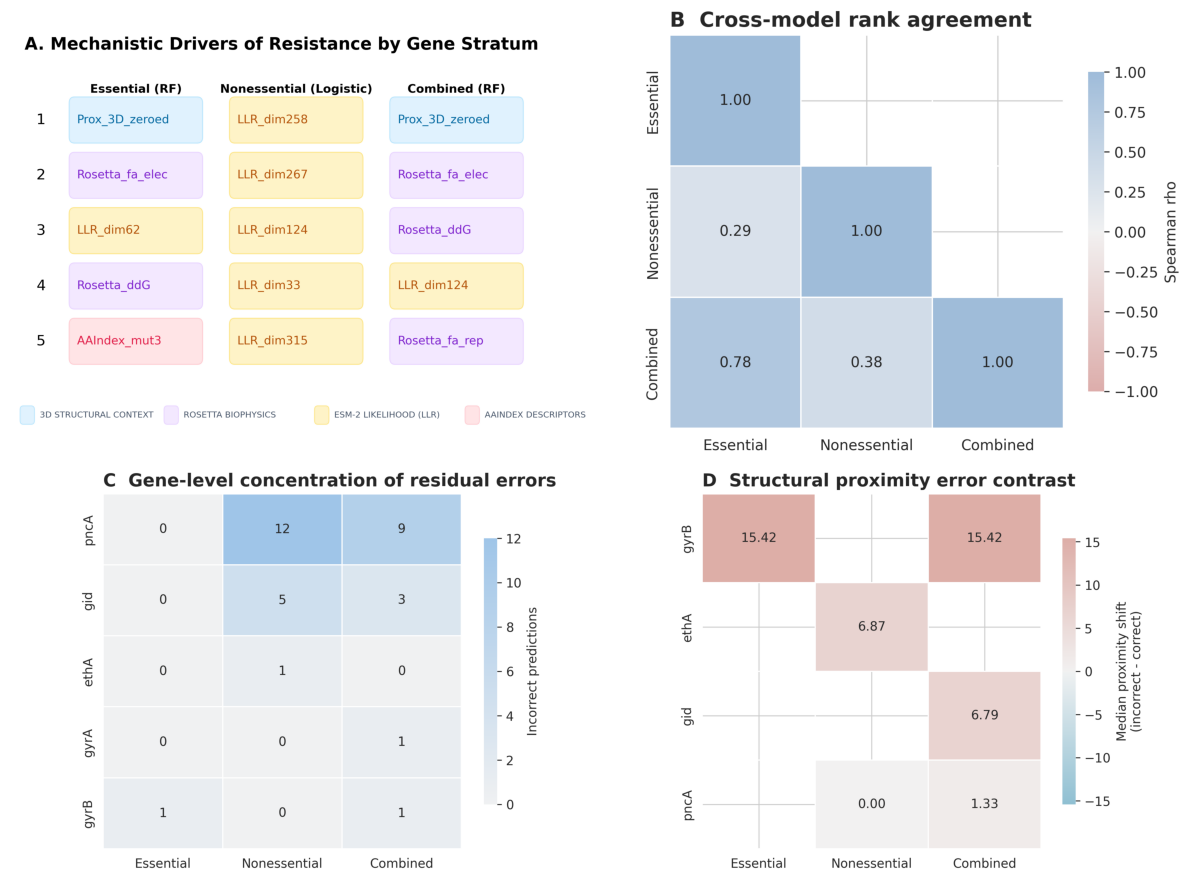

Saved preview composite to: results/figure3_panels/fig3_preview_composite.png


In [68]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def resolve_results_dir() -> Path:
    candidates = [Path("./results")]
    required = ["figure3_panels/mechanistic-drivers-resistance.png"]
    for candidate in candidates:
        if all((candidate / rel).exists() for rel in required):
            return candidate
    raise FileNotFoundError(f"Could not locate results directory from candidates: {candidates}")


results_dir = resolve_results_dir()
figdir = results_dir / "figure3_panels"

# Use PNGs for quick preview
panel_files = {
    "A": figdir / "mechanistic-drivers-resistance.png",
    "B": figdir / "fig3B_rank_agreement.png",
    "C": figdir / "fig3C_residual_gene_heatmap.png",
    "D": figdir / "fig3D_structural_proximity_contrast.png",
}

for key, path in panel_files.items():
    if not path.exists():
        print(f"Missing {key}: {path}")

imgs = {k: mpimg.imread(v) for k, v in panel_files.items() if v.exists()}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    gridspec_kw={"height_ratios": [1.15, 1.0], "width_ratios": [1.15, 1.0]}
)

axes = axes.ravel()

# A
axes[0].imshow(imgs["A"])
axes[0].axis("off")

# B
axes[1].imshow(imgs["B"])
axes[1].axis("off")

# C
axes[2].imshow(imgs["C"])
axes[2].axis("off")

# D
axes[3].imshow(imgs["D"])
axes[3].axis("off")

plt.tight_layout()
plt.savefig(figdir / "fig3_preview_composite.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved preview composite to:", figdir / "fig3_preview_composite.png")
